# Sensitivity Matrix & V-Mode Information Analysis

**Author:** Aaron Roodman  
**Date Created:** 2026-03-08  
**Last Modified:** 2026-03-14  
**Status:** In Progress  
**Keywords:** Rubin Observatory, AOS, Sensitivity Matrix, SVD, V-modes, Control, Double-Zernike

## Description

Comprehensive analysis of the AOS sensitivity matrix SVD decomposition and v-mode properties,
following the formalism in *AOS Control Equations*.

Key functionality:
1. Build the raw and normalized sensitivity matrices A and Ã
2. SVD decomposition: U, Σ, V and their physical interpretation
3. V-mode composition in DOF space (normalized and physical units)
4. V-mode wavefront signatures (Zernike patterns)
5. Control equations: v-mode amplitudes, DOF corrections, round-trip tests
6. Noise amplification and information content per mode
7. Control gain analysis and convergence
8. Comparison across DOF sets (10, 22, 30, 50)
9. Summary table
10. Double-Zernike v-mode decomposition and crosstalk analysis

**Output:** Plots and tables characterizing AOS v-modes, noise properties, and control behavior

**Conventions:**
- V-modes are numbered starting from **1** (not 0)
- Truncation: 10 DOF → 10 v-modes, 22+ DOF → 12 v-modes

**Based on:**
- AOS Control Equations reference document
- ts_ofc sensitivity matrix infrastructure
- truncation_thresholds.ipynb (predecessor notebook)

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-03-08 | Aaron Roodman | Initial version |
| 2026-03-14 | Aaron Roodman | Added per-Zernike noise from covM86, expanded control gain discussion, added 1/3-step delay convergence, physical DOF coefficients in Sec 3.2 |
| 2026-03-25 | Aaron Roodman | Use StateEstimator for SVD and DOF↔v-mode conversion, added Code section, updated DOF sets (added standard_21 and extended_25; dropped extended_30), fixed Sec 3.2 to rank by normalized V_jk but display physical coefficients |
| 2026-03-25 | Aaron Roodman | Fix DOF mask setup: use comp_dof_idx setter and zn_selected setter on OFCData, add make_comp_dof_idx helper, add validation of custom SVD vs StateEstimator for standard_22 |
| 2026-04-07 | Aaron Roodman | Updated to v13 OFC config, added standard_24 DOF set, decomposed normalization weights into r_j and f_j components, fixed DZ achievability to use orthonormal U, expanded DZ heatmaps, added FWHM-only normalization option |

## Table of Contents

1. [Imports](#Imports)
2. [Configuration](#Configuration)
3. [Custom Code](#Code)
4. [Sensitivity Matrix](#Sensitivity%20Matrix)
5. [SVD Decomposition](#SVD%20Decomposition)
6. [V-Mode Analysis](#V-Mode%20Analysis)
7. [Zernike Patterns](#Zernike%20Patterns)
8. [Control Equations](#Control%20Equations)
9. [Noise Amplification](#Noise%20Amplification)
10. [Control Gain](#Control%20Gain)
11. [DOF Set Comparison](#DOF%20Set%20Comparison)
12. [DOF Set Comparisons](#DOF%20Set%20Comparisons)
13. [Double-Zernike](#Double-Zernike)

<a id='Imports' ></a>
## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib import colors, cm
from matplotlib.backends.backend_pdf import PdfPages
from lsst.ts.ofc import OFC, OFCData, SensitivityMatrix, StateEstimator

%load_ext autoreload
%autoreload 2
%matplotlib inline
from lsst.ts.ofc import BendModeToForce
from lsst.ts.wep.utils import convertZernikesToPsfWidth
import scipy.io

<a id='Configuration' ></a>
## Configuration

In [ ]:
# --- OFC config path ---
ofc_config_dir = '/home/r/roodman/u/LSST/packages/ts_config_mttcs/MTAOS/v13/ofc'

# --- DOF labels (all 50) ---
labels_50dof = [
    'M2_dz', 'M2_dx', 'M2_dy', 'M2_rx', 'M2_ry',
    'Cam_dz', 'Cam_dx', 'Cam_dy', 'Cam_rx', 'Cam_ry',
    'B1_1', 'B1_2', 'B1_3', 'B1_4', 'B1_5',
    'B1_6', 'B1_7', 'B1_8', 'B1_9', 'B1_10',
    'B1_11', 'B1_12', 'B1_13', 'B1_14', 'B1_15',
    'B1_16', 'B1_17', 'B1_18', 'B1_19', 'B1_20',
    'B2_1', 'B2_2', 'B2_3', 'B2_4', 'B2_5',
    'B2_6', 'B2_7', 'B2_8', 'B2_9', 'B2_10',
    'B2_11', 'B2_12', 'B2_13', 'B2_14', 'B2_15',
    'B2_16', 'B2_17', 'B2_18', 'B2_19', 'B2_20',
]

# --- DOF subsets (must be sorted — OFCData.dof_idx returns sorted indices) ---
# hexapod_10:   Camera and M2 hexapods only (5+5 rigid body DOFs)
# standard_21:  Hexapods (without M2_dz) + 7 M1M3 bending modes + 5 M2 bending modes
# standard_22:  AOS operational default for months — adds M2_dz to standard_21
# standard_24:  Adds M2 bending modes B2_6 and B2_7 to standard_22
# extended_25:  Adds 3 higher-order mirror modes (B1_12, B1_20, B2_18) — may be
#               difficult to control with only the 4 corner WFS
# all_50:       All 50 degrees of freedom
dof_sets = {
    'hexapod_10': list(range(0, 10)),
    'standard_21': sorted(list(range(1, 17)) + list(range(30, 35))),
    'standard_22': sorted(list(range(0, 17)) + list(range(30, 35))),
    'standard_24': sorted(list(range(0, 17)) + list(range(30, 37))),
    'extended_25': sorted(list(range(0, 17)) + list(range(30, 35)) + [21, 29, 47]),
    'all_50': list(range(0, 50)),
}

# --- Zernike selection ---
zn = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26])
zn_idx = zn - 4
n_zernike = len(zn_idx)

# --- WFS corners ---
sensor_name_list = ['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0']
n_wfs = len(sensor_name_list)

# --- Default DOF set for detailed analysis ---
default_dof_set = 'standard_22'

# --- V-mode truncation: how many modes to retain for each DOF set ---
n_modes_truncated = {
    'hexapod_10': 10,
    'standard_21': 12,
    'standard_22': 12,
    'standard_24': 14,
    'extended_25': 20,
    'all_50': 12,
}

# --- Normalization option ---
# Set to True to use only FWHM weights (no range component) for normalization
use_fwhm_only = False

# --- Markers for multi-line plots ---
marker_cycle = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p', '<', '>']

print(f'Zernike terms: {zn} ({n_zernike} terms)')
print(f'WFS sensors: {sensor_name_list} ({n_wfs} sensors)')
print(f'Measurement vector size: {n_zernike} x {n_wfs} = {n_zernike * n_wfs}')
for name, dofs in dof_sets.items():
    ntrunc = n_modes_truncated[name]
    print(f'DOF set "{name}": {len(dofs)} DOFs, truncated to {ntrunc} v-modes')

<a id='Code' ></a>
## Custom Code

Helper functions that supplement `StateEstimator` functionality.
These are used by the analysis sections below.

In [ ]:
def make_comp_dof_idx(dof_idx_list):
    """Convert a list of active DOF indices (0-49) to the comp_dof_idx dict
    expected by OFCData.comp_dof_idx setter.

    Component layout (50 DOFs total):
        m2HexPos:  indices 0–4   (5)
        camHexPos: indices 5–9   (5)
        M1M3Bend:  indices 10–29 (20)
        M2Bend:    indices 30–49 (20)
    """
    dof_set = set(dof_idx_list)
    components = {
        'm2HexPos':  (0, 5),
        'camHexPos': (5, 5),
        'M1M3Bend':  (10, 20),
        'M2Bend':    (30, 20),
    }
    return {
        name: np.array([start + i in dof_set for i in range(length)], dtype=bool)
        for name, (start, length) in components.items()
    }


def vmode_amplitudes(z_measured, svd_result):
    """Compute v-mode amplitudes: a_k = U^T_k @ z_measured.

    Parameters
    ----------
    z_measured : array (n_z * n_wfs,)
        Concatenated Zernike measurements from all WFS.
    svd_result : dict
        SVD result dict with keys U, s, V.

    Returns
    -------
    a : array (n_modes,)
        V-mode amplitudes in microns of wavefront.
    """
    return svd_result['U'].T @ z_measured


def dimensionless_dof_correction(z_measured, svd_result, n_modes_use=None):
    """Compute dimensionless DOF correction: q = V @ Sigma^-1 @ U^T @ z.

    Parameters
    ----------
    z_measured : array (n_z * n_wfs,)
    svd_result : dict
    n_modes_use : int or None
        Number of modes to retain (truncation). None = all.

    Returns
    -------
    q : array (n_dof,)
        Dimensionless DOF corrections.
    """
    a = vmode_amplitudes(z_measured, svd_result)
    s = svd_result['s']
    V = svd_result['V']
    if n_modes_use is None:
        n_modes_use = len(s)
    return V[:, :n_modes_use] @ (a[:n_modes_use] / s[:n_modes_use])


def physical_dof_correction(z_measured, svd_result, norm_vec, n_modes_use=None):
    """Compute physical DOF correction: delta_dof_j = n_j * q_j.

    Parameters
    ----------
    z_measured : array (n_z * n_wfs,)
    svd_result : dict
    norm_vec : array (n_dof_full,)
        Full normalization vector (50 entries).
    n_modes_use : int or None

    Returns
    -------
    delta_dof : array (n_dof,)
        Physical DOF corrections in microns or degrees.
    """
    q = dimensionless_dof_correction(z_measured, svd_result, n_modes_use)
    n_sub = norm_vec[svd_result['dof_indices']]
    return n_sub * q


print('Custom code functions defined.')

# --- Stdout tee for PDF capture ---
import sys

_tee_buf = None
_tee_old_stdout = None

class _Tee:
    def __init__(self, *streams):
        self.streams = streams
    def write(self, data):
        for s in self.streams:
            s.write(data)
    def flush(self):
        for s in self.streams:
            s.flush()

def pdf_tee_start():
    """Start capturing stdout to buffer while still printing to console."""
    global _tee_buf, _tee_old_stdout
    _tee_buf = io.StringIO()
    _tee_old_stdout = sys.stdout
    sys.stdout = _Tee(_tee_old_stdout, _tee_buf)

def pdf_tee_stop():
    """Stop capturing stdout and write captured text to PDF."""
    global _tee_buf, _tee_old_stdout
    sys.stdout = _tee_old_stdout
    _text = _tee_buf.getvalue()
    if _text.strip():
        pdf_text_page(_text, fontsize=9)
    _tee_buf = None
    _tee_old_stdout = None


def compute_normalization_components(ofc_data, dz_sensitivity_matrix, field_angles):
    """Compute range and FWHM normalization weight components.

    Follows ts_ofc generate_normalization_weights.compute_normalization_weights.

    Parameters
    ----------
    ofc_data : OFCData
    dz_sensitivity_matrix : SensitivityMatrix
    field_angles : list of (float, float)

    Returns
    -------
    range_weights : array (50,)
        Range component r_j of normalization weights.
    fwhm_weights : array (50,)
        FWHM component f_j of normalization weights.
    """
    # Range weights r_j
    m1m3_bending_range = ofc_data.m1m3_force_range / 20
    m2_bending_range = ofc_data.m2_force_range / 20

    m1m3_bmf = BendModeToForce('M1M3', ofc_data)
    m2_bmf = BendModeToForce('M2', ofc_data)

    range_weights = np.concatenate((
        ofc_data.rb_stroke,
        m1m3_bending_range / np.max(np.abs(m1m3_bmf.rot_mat), axis=0),
        m2_bending_range / np.max(np.abs(m2_bmf.rot_mat), axis=0),
    ))

    # FWHM weights f_j
    sensitivity_matrix = dz_sensitivity_matrix.evaluate(field_angles, rotation_angle=0.0)
    sensitivity_matrix = sensitivity_matrix[:, ofc_data.zn_idx, :]

    fwhm_matrix = np.zeros(sensitivity_matrix.shape)
    for idy in range(sensitivity_matrix.shape[0]):
        fwhm_matrix[idy, ...] = convertZernikesToPsfWidth(sensitivity_matrix[idy, ...].T).T

    fwhm_matrix_2d = fwhm_matrix.reshape((-1, fwhm_matrix.shape[2]))
    fwhm_weights = np.zeros(50)
    for i in range(50):
        fwhm_weights[i] = np.sqrt(np.sum(np.square(fwhm_matrix_2d[:, i])))

    return range_weights, fwhm_weights


In [ ]:
# --- PDF output setup ---
import io, contextlib

wgt_tag = 'fwgt' if use_fwhm_only else 'rfwgt'
pdf_filename = f'output/smatrix_vmode_info_{default_dof_set}_{wgt_tag}.pdf'

pdf = PdfPages(pdf_filename)
print(f'PDF output: {pdf_filename}')

def pdf_text_page(text, fontsize=14):
    """Add a text-only page to the PDF."""
    fig_pdf = plt.figure(figsize=(11, 8.5))
    fig_pdf.text(0.05, 0.95, text, transform=fig_pdf.transFigure,
                 fontsize=fontsize, verticalalignment='top',
                 fontfamily='monospace', wrap=True)
    plt.axis('off')
    pdf.savefig(fig_pdf)
    plt.close(fig_pdf)

def pdf_section(title, body=''):
    """Add a section header page to the PDF."""
    text = title + '\n' + '=' * len(title)
    if body:
        text += '\n\n' + body
    pdf_text_page(text, fontsize=16)

def pdf_save(fig):
    """Save current figure to PDF."""
    pdf.savefig(fig, bbox_inches='tight')

def pdf_capture_print(func):
    """Run func, capture stdout, print it, and add as PDF text page."""
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        func()
    text = buf.getvalue()
    print(text)
    pdf_text_page(text, fontsize=9)

<a id='Sensitivity Matrix' ></a>
## 1. Sensitivity Matrix

Build the raw sensitivity matrix **A** and the normalized matrix **Ã = A @ diag(n_j)**.

- **A** maps physical DOF motions to Zernike wavefront changes (units: microns/Zernike per physical DOF unit)
- **Ã** normalizes each DOF column by n_j = r_j × f_j, placing all DOFs on equal (dimensionless) footing

In [ ]:
pdf_section('1. Sensitivity Matrix')
# Load OFC data and build the sensitivity matrix at the 4 corner WFS positions
ofc_data = OFCData('lsst', config_dir=ofc_config_dir)
ofc_data.zn_selected = zn

field_angles = [ofc_data.sample_points[sensor] for sensor in sensor_name_list]
print('Field angles (deg):', field_angles)

dz_sensitivity_matrix = SensitivityMatrix(ofc_data)
sens_3d = dz_sensitivity_matrix.evaluate(field_angles, 0.0)
print(f'Raw 3D sensitivity matrix shape: {sens_3d.shape}  (n_wfs, n_zernike_full, n_dof_full)')

# Select Zernike subset and reshape to 2D: rows = (Zernike x WFS), cols = DOFs
sens_3d = sens_3d[:, zn_idx, :]
A_full = sens_3d.reshape((-1, sens_3d.shape[2]))

# Select active DOF indices
A_full = A_full[:, ofc_data.dof_idx]
print(f'Raw sensitivity matrix A shape: {A_full.shape}  (n_zernike*n_wfs, n_dof)')

# Normalization vector n_j for each DOF
norm_vector = ofc_data.normalization_weights[ofc_data.dof_idx]
print(f'Normalization vector shape: {norm_vector.shape}')

# Normalized sensitivity matrix: Atilde = A @ diag(n_j)
Atilde_full = A_full @ np.diag(norm_vector)
print(f'Normalized sensitivity matrix Atilde shape: {Atilde_full.shape}')

# Optionally override normalization to use FWHM weights only
if use_fwhm_only:
    print('*** Using FWHM-only normalization weights (overriding range component) ***')
    # Will be computed in Sec 1.3; for now store the flag
    _fwhm_only_flag = True
else:
    _fwhm_only_flag = False

### 1.1 Sensitivity Matrix Visualization

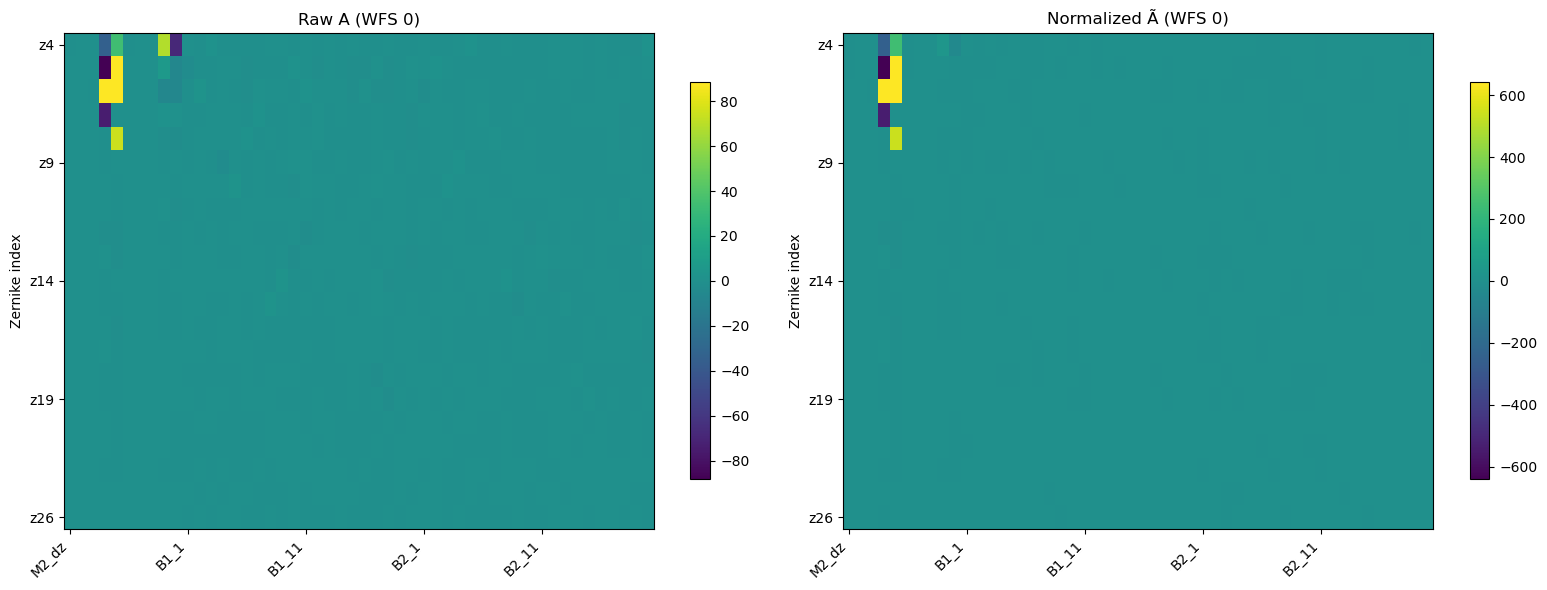

In [13]:
pdf_section('1.1 Sensitivity Matrix Visualization')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw A (first WFS only for clarity)
r0 = axes[0].imshow(A_full[:n_zernike, :], aspect='auto')
axes[0].set_title('Raw A (WFS 0)')
axes[0].set_ylabel('Zernike index')
axes[0].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
xt = np.arange(0, 50, 10)
axes[0].set_xticks(xt, [labels_50dof[i] for i in xt], rotation=45, ha='right')
fig.colorbar(r0, ax=axes[0], shrink=0.8)

# Normalized Atilde (first WFS only)
r1 = axes[1].imshow(Atilde_full[:n_zernike, :], aspect='auto')
axes[1].set_title('Normalized Ã (WFS 0)')
axes[1].set_ylabel('Zernike index')
axes[1].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
axes[1].set_xticks(xt, [labels_50dof[i] for i in xt], rotation=45, ha='right')
fig.colorbar(r1, ax=axes[1], shrink=0.8)

fig.tight_layout()
pdf_save(fig)
plt.show()

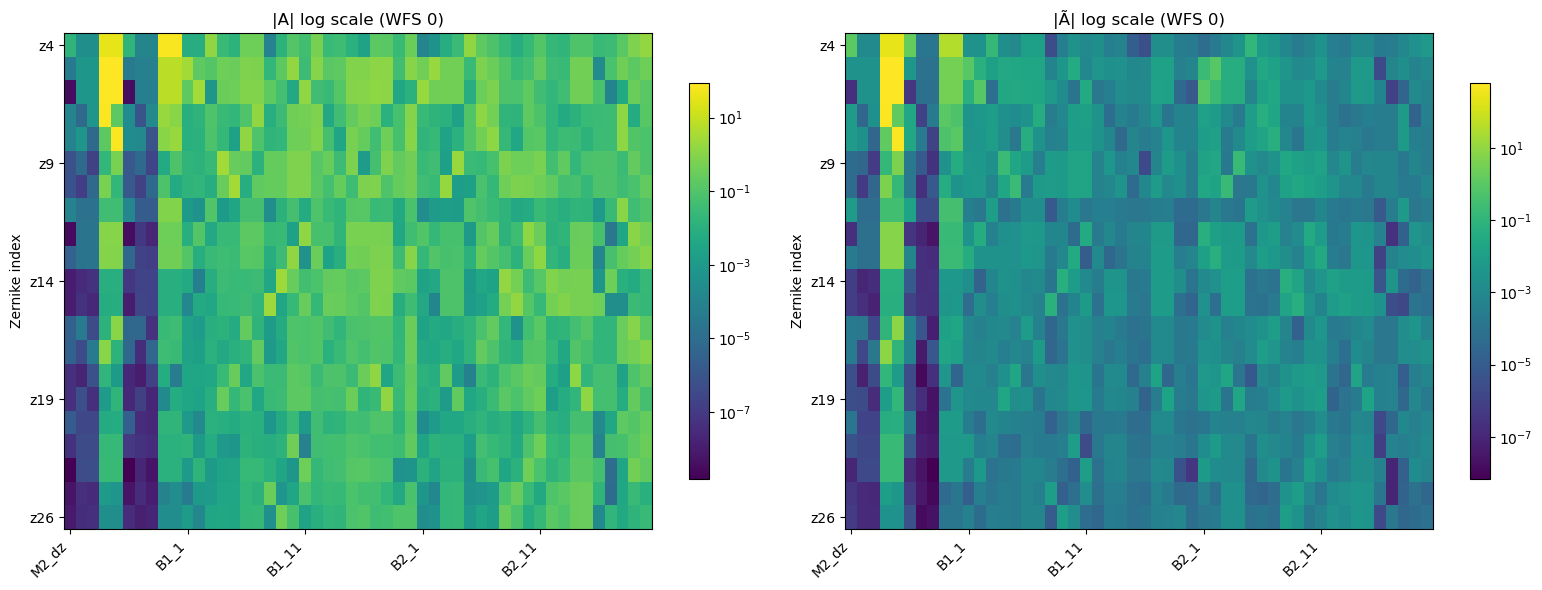

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# |A| log scale
r0 = axes[0].imshow(np.abs(A_full[:n_zernike, :]), aspect='auto', norm=colors.LogNorm())
axes[0].set_title('|A| log scale (WFS 0)')
axes[0].set_ylabel('Zernike index')
axes[0].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
xt = np.arange(0, 50, 10)
axes[0].set_xticks(xt, [labels_50dof[i] for i in xt], rotation=45, ha='right')
fig.colorbar(r0, ax=axes[0], shrink=0.8)

# |Atilde| log scale
r1 = axes[1].imshow(np.abs(Atilde_full[:n_zernike, :]), aspect='auto', norm=colors.LogNorm())
axes[1].set_title('|Ã| log scale (WFS 0)')
axes[1].set_ylabel('Zernike index')
axes[1].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
axes[1].set_xticks(xt, [labels_50dof[i] for i in xt], rotation=45, ha='right')
fig.colorbar(r1, ax=axes[1], shrink=0.8)

fig.tight_layout()
pdf_save(fig)
plt.show()

### 1.2 Normalization Weights

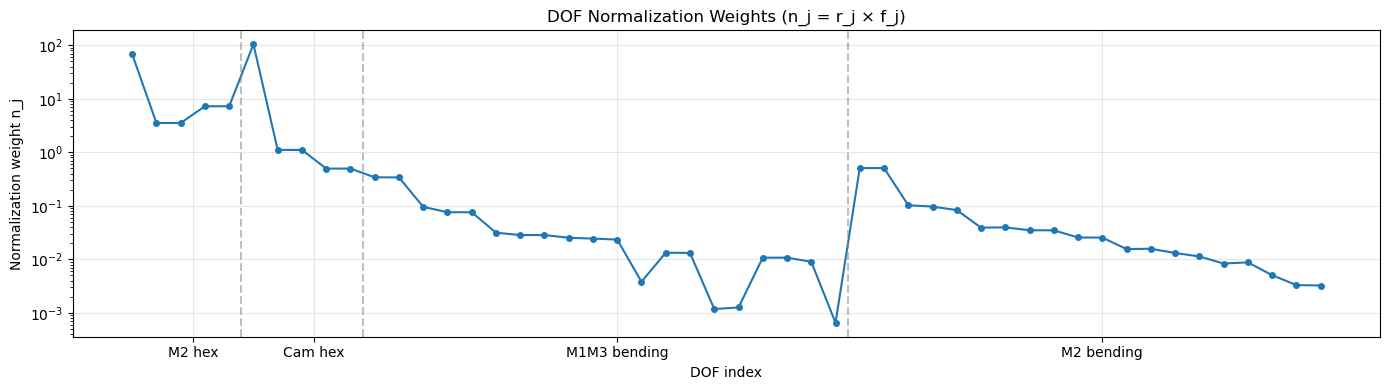

In [15]:
pdf_section('1.2 Normalization Weights')
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.semilogy(norm_vector, 'o-', markersize=4)
ax.set_xlabel('DOF index')
ax.set_ylabel('Normalization weight n_j')
ax.set_title('DOF Normalization Weights (n_j = r_j × f_j)')
# Mark boundaries
for xv in [5, 10, 30]:
    ax.axvline(xv - 0.5, color='gray', ls='--', alpha=0.5)
ax.set_xticks([2.5, 7.5, 20, 40], ['M2 hex', 'Cam hex', 'M1M3 bending', 'M2 bending'])
ax.grid(alpha=0.3)
fig.tight_layout()
pdf_save(fig)
plt.show()

### 1.3 Normalization Weight Decomposition

The normalization weight for each DOF is n_j = r_j × f_j, where:
- **r_j (range weight):** physical range of each DOF — hexapod stroke or bending mode force range divided by max rotation matrix element
- **f_j (FWHM weight):** sensitivity of FWHM to each DOF — RSS of the FWHM sensitivity across field positions

These are computed by `generate_normalization_weights` in `ts_ofc`.

In [ ]:
pdf_tee_start()

pdf_section('1.3 Normalization Weight Decomposition')

# Compute range and FWHM weights using the helper function
range_weights, fwhm_weights = compute_normalization_components(
    ofc_data, dz_sensitivity_matrix, field_angles)

# Combined: n_j = r_j * f_j
norm_computed = range_weights * fwhm_weights

# Validate against ofc_data
norm_stored = ofc_data.normalization_weights
max_diff = np.max(np.abs(norm_computed - norm_stored))
print(f'Normalization weight validation: max |computed - stored| = {max_diff:.2e}')
if max_diff < 1e-10:
    print('PASS: computed weights match stored weights')
else:
    print('WARNING: mismatch detected')
    for i in range(50):
        if abs(norm_computed[i] - norm_stored[i]) > 1e-10:
            ratio = norm_computed[i] / norm_stored[i] if norm_stored[i] != 0 else float('inf')
            print(f'  DOF {i:2d} ({labels_50dof[i]:>20s}): '
                  f'computed={norm_computed[i]:.6e}, stored={norm_stored[i]:.6e}, '
                  f'ratio={ratio:.4f}')

# Apply FWHM-only override if requested
if _fwhm_only_flag:
    print('\n*** Overriding normalization weights with FWHM-only ***')
    norm_vector[:] = fwhm_weights[ofc_data.dof_idx]
    Atilde_full = A_full @ np.diag(norm_vector)
    print(f'norm_vector now uses fwhm_weights only')

pdf_tee_stop()


In [ ]:
# Plot range weights, FWHM weights, and combined
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].semilogy(range_weights, 'o-', markersize=4, color='steelblue')
axes[0].set_ylabel('Range weight r_j')
axes[0].set_title('Range Weights r_j (physical stroke / max force-to-mode)')
for xv in [5, 10, 30]:
    axes[0].axvline(xv - 0.5, color='gray', ls='--', alpha=0.5)
axes[0].grid(alpha=0.3)

axes[1].semilogy(fwhm_weights, 'o-', markersize=4, color='coral')
axes[1].set_ylabel('FWHM weight f_j')
axes[1].set_title('FWHM Weights f_j (RSS of FWHM sensitivity across field)')
for xv in [5, 10, 30]:
    axes[1].axvline(xv - 0.5, color='gray', ls='--', alpha=0.5)
axes[1].grid(alpha=0.3)

axes[2].semilogy(norm_vector, 'o-', markersize=4, color='green')
axes[2].set_ylabel('n_j = r_j * f_j')
axes[2].set_title('Combined Normalization Weights n_j = r_j * f_j')
for xv in [5, 10, 30]:
    axes[2].axvline(xv - 0.5, color='gray', ls='--', alpha=0.5)
axes[2].grid(alpha=0.3)

axes[2].set_xlabel('DOF index')
axes[2].set_xticks([2.5, 7.5, 20, 40], ['M2 hex', 'Cam hex', 'M1M3 bending', 'M2 bending'])

fig.tight_layout()
pdf_save(fig)
plt.show()

# Normalized sensitivity matrix comparison: stored vs computed weights (WFS 0)
dof_idx = ofc_data.dof_idx
n_computed = norm_computed[dof_idx]
n_stored = norm_stored[dof_idx]
Atilde_stored = A_full @ np.diag(n_stored)
Atilde_computed = A_full @ np.diag(n_computed)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Stored weights
vmax = max(np.abs(Atilde_stored[:n_zernike, :]).max(),
           np.abs(Atilde_computed[:n_zernike, :]).max())
im0 = axes[0].imshow(Atilde_stored[:n_zernike, :], aspect='auto',
                      vmin=-vmax, vmax=vmax, cmap='RdBu_r')
axes[0].set_title('Ã stored weights (WFS 0)')
axes[0].set_ylabel('Zernike index')
axes[0].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
fig.colorbar(im0, ax=axes[0], shrink=0.8)

# Computed weights
im1 = axes[1].imshow(Atilde_computed[:n_zernike, :], aspect='auto',
                      vmin=-vmax, vmax=vmax, cmap='RdBu_r')
axes[1].set_title('Ã computed weights (WFS 0)')
axes[1].set_ylabel('Zernike index')
axes[1].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
fig.colorbar(im1, ax=axes[1], shrink=0.8)

# Difference
diff_matrix = Atilde_computed[:n_zernike, :] - Atilde_stored[:n_zernike, :]
dmax = np.abs(diff_matrix).max()
if dmax < 1e-15:
    dmax = 1.0  # avoid zero range
im2 = axes[2].imshow(diff_matrix, aspect='auto',
                      vmin=-dmax, vmax=dmax, cmap='RdBu_r')
axes[2].set_title(f'Difference (max={dmax:.2e})')
axes[2].set_ylabel('Zernike index')
axes[2].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
fig.colorbar(im2, ax=axes[2], shrink=0.8)

# DOF labels on x-axis
n_dof = Atilde_stored.shape[1]
xt = np.linspace(0, n_dof - 1, min(n_dof, 10), dtype=int)
dof_labels = [labels_50dof[dof_idx[j]] for j in xt]
for ax in axes:
    ax.set_xticks(xt)
    ax.set_xticklabels(dof_labels, rotation=45, ha='right', fontsize=8)

fig.suptitle('Normalized Sensitivity Matrix: Stored vs Computed Weights', fontsize=13)
fig.tight_layout()
pdf_save(fig)
plt.show()


### 1.4 Inspect Individual Sensitivity Matrix Elements

Look up a specific (DOF, Zernike, WFS) element of the sensitivity matrix,
showing the raw value and normalized values using both stored and computed weights.

In [ ]:
# --- Configuration: choose DOF, Zernike, and WFS to inspect ---
inspect_dof_name = 'Cam_rx'      # DOF name from labels_50dof
inspect_zernike = 5              # Noll index
inspect_wfs = 'R00_SW0'          # WFS sensor name

pdf_tee_start()
pdf_section('1.4 Inspect Individual Sensitivity Matrix Elements')

# Resolve indices
dof_idx_full = labels_50dof.index(inspect_dof_name)  # 0-49
dof_idx_active = list(ofc_data.dof_idx).index(dof_idx_full)  # column in A_full
zk_pos = list(zn).index(inspect_zernike)  # row within one WFS block
wfs_idx = sensor_name_list.index(inspect_wfs)  # WFS block index

row = wfs_idx * n_zernike + zk_pos

# Raw sensitivity matrix element
a_raw = A_full[row, dof_idx_active]

# Normalization weights
n_stored = norm_stored[dof_idx_full]
n_computed = norm_computed[dof_idx_full]
r_j = range_weights[dof_idx_full]
f_j = fwhm_weights[dof_idx_full]

# Normalized values
a_norm_stored = a_raw * n_stored
a_norm_computed = a_raw * n_computed

print(f'DOF:     {inspect_dof_name} (index {dof_idx_full})')
print(f'Zernike: z{inspect_zernike} (Noll)')
print(f'WFS:     {inspect_wfs} (index {wfs_idx})')
print()
print(f'Raw sensitivity A[z{inspect_zernike}, {inspect_dof_name}] = {a_raw:.6e} µm/unit')
print()
print(f'Normalization weights for {inspect_dof_name}:')
print(f'  Range weight   r_j = {r_j:.6e}')
print(f'  FWHM weight    f_j = {f_j:.6e}')
print(f'  Stored   n_j       = {n_stored:.6e}')
print(f'  Computed r_j * f_j = {n_computed:.6e}')
if n_stored != 0:
    print(f'  Ratio computed/stored = {n_computed / n_stored:.6f}')
print()
print(f'Normalized Ã[z{inspect_zernike}, {inspect_dof_name}]:')
print(f'  With stored weights:   {a_norm_stored:.6e}')
print(f'  With computed weights: {a_norm_computed:.6e}')
if a_norm_stored != 0:
    print(f'  Ratio: {a_norm_computed / a_norm_stored:.6f}')

# Also show all WFS values for this DOF and Zernike
print(f'\nAll WFS values for z{inspect_zernike} x {inspect_dof_name}:')
print(f'  {"WFS":>10s}  {"A (raw)":>12s}  {"Ã stored":>12s}  {"Ã computed":>12s}')
for iwfs, wfs_name in enumerate(sensor_name_list):
    r = iwfs * n_zernike + zk_pos
    a_val = A_full[r, dof_idx_active]
    print(f'  {wfs_name:>10s}  {a_val:>12.6e}  {a_val * n_stored:>12.6e}  {a_val * n_computed:>12.6e}')

# Show all Zernike values for this DOF and WFS
print(f'\nAll Zernike values for {inspect_wfs} x {inspect_dof_name}:')
print(f'  {"Zernike":>10s}  {"A (raw)":>12s}  {"Ã stored":>12s}  {"Ã computed":>12s}')
for izk, zn_val in enumerate(zn):
    r = wfs_idx * n_zernike + izk
    a_val = A_full[r, dof_idx_active]
    print(f'  {"z" + str(zn_val):>10s}  {a_val:>12.6e}  {a_val * n_stored:>12.6e}  {a_val * n_computed:>12.6e}')

pdf_tee_stop()


<a id='SVD Decomposition' ></a>
## 2. SVD Decomposition

Decompose the normalized sensitivity matrix: **Ã = U Σ Vᵀ**

- **U** (n_z×n_wfs, n_modes): left singular vectors — Zernike measurement patterns
- **Σ** (n_modes, n_modes): singular values — wavefront change per unit dimensionless DOF motion
- **V** (n_dof, n_modes): right singular vectors — DOF composition of each v-mode

In [ ]:
pdf_tee_start()

pdf_section('2. SVD Decomposition')
# Create StateEstimator for each DOF set using OFC code
# StateEstimator computes SVD internally: U, S, Vh = svd(A[:, dof_idx] @ N)
# Note: StateEstimator's U is in DZ coefficient space (not WFS×Zernike).
# We also compute U_wfs for per-WFS visualization and noise calculations.
state_estimators = {}
svd_results = {}

for name, dof_idx_list in dof_sets.items():
    ofc_i = OFCData('lsst', config_dir=ofc_config_dir)
    ofc_i.comp_dof_idx = make_comp_dof_idx(dof_idx_list)
    ofc_i.zn_selected = zn
    ofc_i.controller['truncation_index'] = n_modes_truncated[name]

    # Verify DOF mask was set correctly
    assert list(ofc_i.dof_idx) == dof_idx_list, \
        f'{name}: dof_idx mismatch: {list(ofc_i.dof_idx)} != {dof_idx_list}'

    se = StateEstimator(ofc_i)
    state_estimators[name] = se

    labels_sub = [labels_50dof[i] for i in dof_idx_list]
    n_sub = norm_vector[dof_idx_list]

    # U_wfs: project DZ-space SVD onto 4-WFS evaluated sensitivity matrix
    # U_wfs = Atilde_wfs @ V @ diag(1/s), where Atilde_wfs = A_full[:, dof_idx] @ diag(n)
    Atilde_wfs = A_full[:, dof_idx_list] @ np.diag(n_sub)
    U_wfs = Atilde_wfs @ se.Vh.T @ np.diag(1.0 / se.S)

    svd_results[name] = dict(
        U=se.U, s=se.S, V=se.Vh.T, Vh=se.Vh,
        U_wfs=U_wfs,
        dof_indices=dof_idx_list, labels=labels_sub,
        Atilde_sub=se.U @ np.diag(se.S) @ se.Vh,
        Atilde_wfs=Atilde_wfs,
        n_modes=len(se.S),
        state_estimator=se,
    )
    r = svd_results[name]
    print(f'{name:15s}: {r["n_modes"]:3d} modes, '
          f'σ_max={r["s"][0]:.2f}, σ_min={r["s"][-1]:.2e}, '
          f'cond={r["s"][0]/r["s"][-1]:.1f}')

se_default = state_estimators[default_dof_set]
r_default = svd_results[default_dof_set]
print(f'\nDefault ({default_dof_set}):')
print(f'  U (DZ space): {se_default.U.shape}')
print(f'  U_wfs (4 WFS): {r_default["U_wfs"].shape}')
print(f'  S: {se_default.S.shape}, Vh: {se_default.Vh.shape}')
print(f'  truncation_index: {se_default.truncate_index}')

# For cells that need WFS-space Zernike dimensions
n_zk_svd = n_zernike
zn_svd = zn

pdf_tee_stop()

### 2.0 Validation: StateEstimator vs Custom SVD

Reproduce the SVD for `standard_22` using the notebook's sensitivity matrix and
compare against StateEstimator's results. Sign flips per mode are expected
(the SVD is unique only up to sign of each singular vector pair).

In [ ]:
pdf_tee_start()

pdf_section('2.0 Validation: StateEstimator vs Custom SVD')
# --- Validation: custom SVD vs StateEstimator for standard_22 ---
dof_idx_22 = dof_sets['standard_22']
n_trunc_22 = n_modes_truncated['standard_22']
r_22 = svd_results['standard_22']
se_22 = r_22['state_estimator']
n_sub_22 = norm_vector[dof_idx_22]

# Build Atilde from the notebook's A_full (evaluated at 4 WFS) for comparison
A_sub = A_full[:, dof_idx_22]
Atilde_notebook = A_sub @ np.diag(n_sub_22)
U_nb, s_nb, Vh_nb = np.linalg.svd(Atilde_notebook, full_matrices=False)
V_nb = Vh_nb.T

# --- 1. Compare sensitivity matrices ---
print('1. Sensitivity matrix shapes:')
print(f'   From StateEstimator (DZ coefficients): {r_22["Atilde_sub"].shape}')
print(f'   From SensitivityMatrix.evaluate (4 WFS): {Atilde_notebook.shape}')
if r_22['Atilde_sub'].shape == Atilde_notebook.shape:
    diff = np.max(np.abs(r_22['Atilde_sub'] - Atilde_notebook))
    print(f'   Max |difference|: {diff:.2e}')
else:
    print('   Different shapes — StateEstimator uses DZ coefficients,')
    print('   notebook uses SensitivityMatrix.evaluate at 4 WFS field angles.')

# --- 2. Compare singular values ---
n_compare = min(n_trunc_22, len(r_22['s']), len(s_nb))
print(f'\n2. Singular value comparison (first {n_compare} modes):')
print(f'{"mode":>5s} {"σ (SE)":>14s} {"σ (4 WFS)":>14s} {"ratio":>10s}')
for k in range(n_compare):
    ratio = r_22['s'][k] / s_nb[k] if s_nb[k] > 0 else np.nan
    print(f'{k+1:>5d} {r_22["s"][k]:>14.4f} {s_nb[k]:>14.4f} {ratio:>10.6f}')

# --- 3. Validate against StateEstimator.get_vmodes_from_dofs ---
np.random.seed(42)
dof_test = np.zeros(50)
dof_test[dof_idx_22] = np.random.randn(len(dof_idx_22))

vmodes_se = se_22.get_vmodes_from_dofs(dof_test)
V_22 = r_22['V']
vmodes_custom = (dof_test[dof_idx_22] / n_sub_22) @ V_22[:, :n_trunc_22]

print(f'\n3. V-mode reconstruction from random DOF state:')
print(f'{"mode":>5s} {"SE":>12s} {"custom":>12s} {"diff":>12s}')
for k in range(n_trunc_22):
    print(f'{k+1:>5d} {vmodes_se[k]:>12.6f} {vmodes_custom[k]:>12.6f} '
          f'{vmodes_se[k] - vmodes_custom[k]:>12.2e}')
max_diff = np.max(np.abs(vmodes_se - vmodes_custom))
print(f'\nMax |vmode_SE - vmode_custom|: {max_diff:.2e}')
if max_diff < 1e-10:
    print('PASS: Custom SVD exactly matches StateEstimator')
elif max_diff < 1e-6:
    print('PASS: Custom SVD matches StateEstimator to numerical precision')
else:
    print('WARNING: Significant difference — check sign flips or matrix source')
    for k in range(n_trunc_22):
        if np.abs(vmodes_se[k] + vmodes_custom[k]) < np.abs(vmodes_se[k] - vmodes_custom[k]):
            print(f'  Mode {k+1}: likely sign flip')

pdf_tee_stop()

### 2.1 Singular Value Spectrum

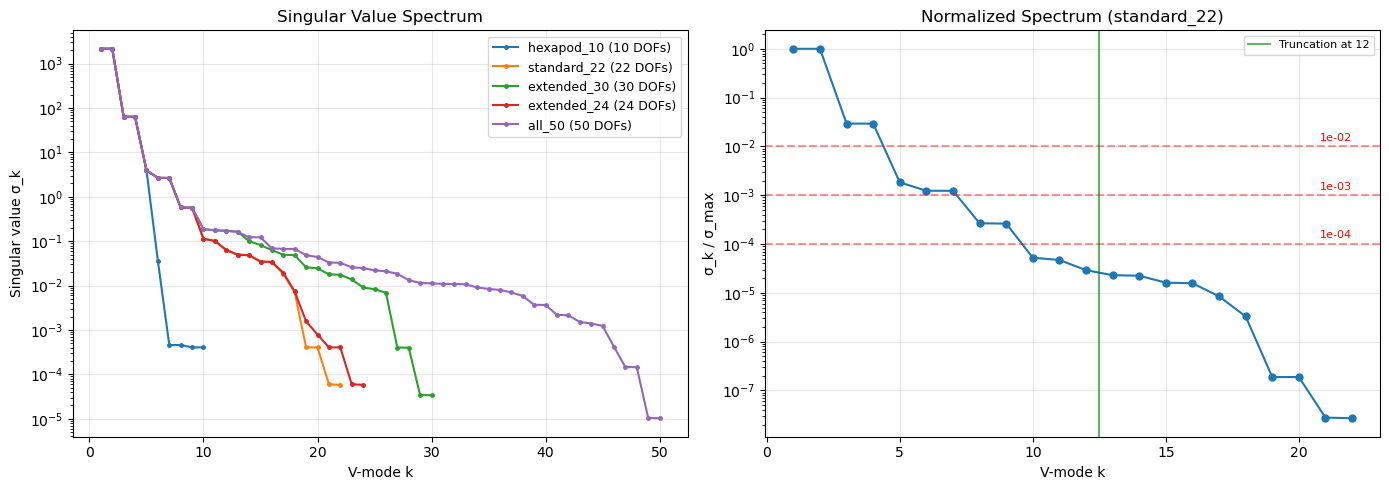

In [17]:
pdf_section('2.1 Singular Value Spectrum')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlay all DOF sets (1-indexed v-modes)
for name, r in svd_results.items():
    axes[0].semilogy(np.arange(1, r['n_modes'] + 1), r['s'], '.-', markersize=5,
                     label=f'{name} ({r["n_modes"]} DOFs)')
axes[0].set_xlabel('V-mode k')
axes[0].set_ylabel('Singular value σ_k')
axes[0].set_title('Singular Value Spectrum')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: normalized σ_k / σ_max for the default set
r = svd_results[default_dof_set]
s_norm = r['s'] / r['s'][0]
axes[1].semilogy(np.arange(1, r['n_modes'] + 1), s_norm, 'o-', markersize=5)
for thresh in [1e-2, 1e-3, 1e-4]:
    axes[1].axhline(thresh, color='red', ls='--', alpha=0.4)
    axes[1].text(r['n_modes'], thresh * 1.3, f'{thresh:.0e}', color='red', fontsize=8, ha='right')
n_trunc = n_modes_truncated[default_dof_set]
axes[1].axvline(n_trunc + 0.5, color='green', ls='-', alpha=0.6, label=f'Truncation at {n_trunc}')
axes[1].set_xlabel('V-mode k')
axes[1].set_ylabel('σ_k / σ_max')
axes[1].set_title(f'Normalized Spectrum ({default_dof_set})')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
pdf_save(fig)
plt.show()

### 2.2 Mode Truncation

Modes with σ_k < threshold × σ_max are truncated. Show how many modes survive at each threshold.

In [ ]:
pdf_tee_start()

pdf_section('2.2 Mode Truncation')
thresholds = [1e-2, 1e-3, 1e-4, 1e-5]

print(f'{"DOF set":>15s} {"n_DOF":>6s} {"n_trunc":>8s}', end='')
for t in thresholds:
    print(f'  thresh={t:.0e}', end='')
print()

for name, r in svd_results.items():
    n_trunc = n_modes_truncated[name]
    print(f'{name:>15s} {len(r["dof_indices"]):>6d} {n_trunc:>8d}', end='')
    for t in thresholds:
        n_kept = np.sum(r['s'] > t * r['s'][0])
        print(f'  {n_kept:>12d}', end='')
    print()

print(f'\nRetained v-modes per DOF set:')
for name, n_trunc in n_modes_truncated.items():
    r = svd_results[name]
    print(f'  {name}: v-modes 1–{n_trunc} of {r["n_modes"]}  '
          f'(σ_{n_trunc}/σ_1 = {r["s"][n_trunc-1]/r["s"][0]:.2e})')

pdf_tee_stop()

<a id='V-Mode Analysis' ></a>
## 3. V-Mode Analysis

Each column of V defines a v-mode: a unit vector in DOF space.
V_jk is the contribution of dimensionless DOF j to v-mode k.

### 3.1 V-Mode Composition in DOF Space

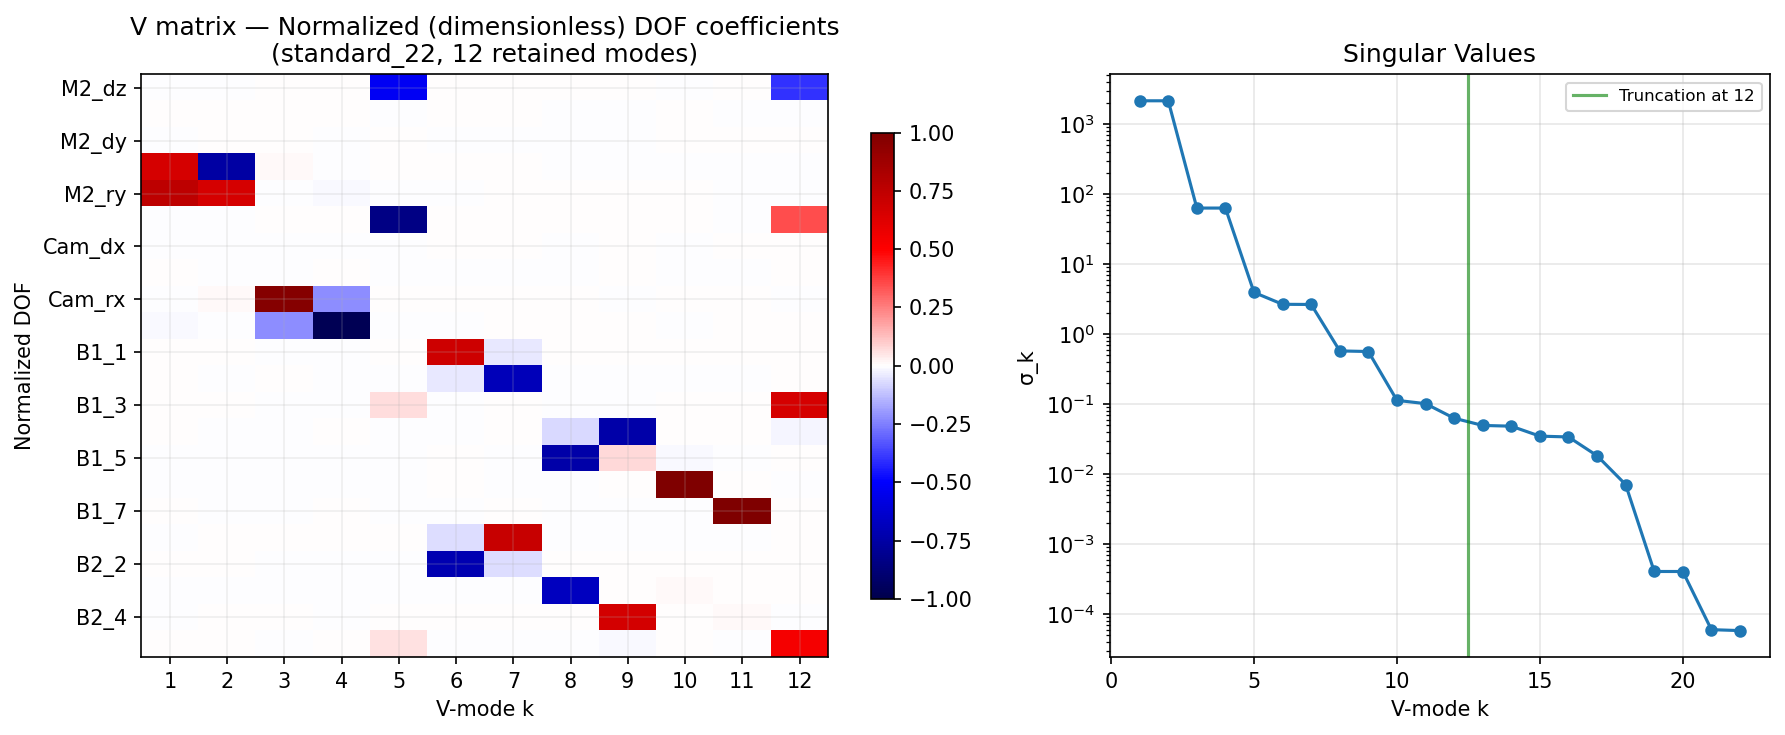

In [19]:
pdf_section('3. V-Mode Analysis')
r = svd_results[default_dof_set]
V = r['V']
s = r['s']
n_dof_sub = len(r['dof_indices'])
labels_sub = r['labels']
n_trunc = n_modes_truncated[default_dof_set]

fig = plt.figure(figsize=(12, 5), dpi=150)
gs = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1])
ax0 = plt.subplot(gs[0])
ax1 = plt.subplot(gs[1])

# V matrix heatmap (show retained modes only)
im = ax0.imshow(V[:, :n_trunc], cmap='seismic', vmin=-1, vmax=1, aspect='auto')
ax0.set_xlabel('V-mode k')
ax0.set_xticks(range(n_trunc), [str(k+1) for k in range(n_trunc)])
ax0.set_ylabel('Normalized DOF')
yt = range(0, n_dof_sub, max(1, n_dof_sub // 8))
ax0.set_yticks(list(yt), [labels_sub[i] for i in yt])
ax0.set_title(f'V matrix — Normalized (dimensionless) DOF coefficients\n({default_dof_set}, {n_trunc} retained modes)')
fig.colorbar(im, ax=ax0, shrink=0.8)
ax0.grid(alpha=0.2)

# Singular values (1-indexed)
ax1.semilogy(np.arange(1, len(s) + 1), s, 'o-', markersize=5)
ax1.axvline(n_trunc + 0.5, color='green', ls='-', alpha=0.6, label=f'Truncation at {n_trunc}')
ax1.set_xlabel('V-mode k')
ax1.set_ylabel('σ_k')
ax1.set_title('Singular Values')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

fig.tight_layout()
pdf_save(fig)
plt.show()

In [ ]:
# Bar charts for the first 12 v-modes — Normalized (dimensionless) DOF coefficients
r = svd_results[default_dof_set]
V = r['V']
s = r['s']
labels_sub = r['labels']
n_show = min(12, V.shape[1])

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for k, ax in enumerate(axes.flat[:n_show]):
    ax.barh(range(len(labels_sub)), V[:, k], color='steelblue')
    ax.set_yticks(range(len(labels_sub)), labels_sub, fontsize=6)
    ax.set_title(f'v-mode {k+1}  (σ={s[k]:.2f})', fontsize=9)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlim(-1.1, 1.1)
    ax.set_xlabel('Normalized DOF coeff', fontsize=7)
    ax.tick_params(axis='x', labelsize=7)
for ax in axes.flat[n_show:]:
    ax.set_visible(False)
fig.suptitle(f'V-mode Composition — Normalized (dimensionless) DOF ({default_dof_set})', fontsize=12)
fig.tight_layout()
pdf_save(fig)

In [ ]:
# Bar charts for the first 12 v-modes — Physical DOF coefficients (V_jk * n_j)
r = svd_results[default_dof_set]
V = r['V']
s = r['s']
labels_sub = r['labels']
n_sub = norm_vector[r['dof_indices']]
n_show = min(12, V.shape[1])

# Physical V: each column is V[:, k] * n_j (physical units per unit v-mode amplitude)
V_phys = V * n_sub[:, np.newaxis]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for k, ax in enumerate(axes.flat[:n_show]):
    ax.barh(range(len(labels_sub)), V_phys[:, k], color='coral')
    ax.set_yticks(range(len(labels_sub)), labels_sub, fontsize=6)
    ax.set_title(f'v-mode {k+1}  (σ={s[k]:.2f})', fontsize=9)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('Physical DOF (µm or deg)', fontsize=7)
    ax.grid(alpha=0.2)
for ax in axes.flat[n_show:]:
    ax.set_visible(False)
fig.suptitle(f'V-mode Composition — Physical DOF units ({default_dof_set})', fontsize=12)
fig.tight_layout()
pdf_save(fig)
plt.show()

### 3.2 Physical DOF Coefficients for V-Mode Reconstruction

The v-modes stored in nightly tables are computed as:

$$\text{vmode}_k = \sum_j V_{jk} \cdot \frac{\text{dof}_j}{n_j}$$

where $V_{jk}$ are the (dimensionless) right singular vectors and $n_j$ are the normalization weights.
To reconstruct v-modes directly from physical DOF values (in µm or degrees), the effective coefficient
for each DOF is $V_{jk} / n_j$.

The table below ranks DOF contributors by their **dimensionless weight** $|V_{jk}|$
(which reflects the true importance in the SVD), but expresses the reconstruction using
**physical coefficients** $V_{jk} / n_j$.  This avoids highlighting DOFs that only appear
large due to their normalization units (e.g. Cam_dz, M2_dz with large $n_j$).

In [ ]:
pdf_tee_start()

pdf_section('3.2 Physical DOF Coefficients for V-Mode Reconstruction')
r = svd_results[default_dof_set]
V = r['V']
labels_sub = r['labels']
n_trunc = n_modes_truncated[default_dof_set]
n_sub = norm_vector[r['dof_indices']]

n_top = 4
print(f'Top {n_top} DOF contributors per v-mode ({default_dof_set}, {n_trunc} retained modes)')
print(f'Ranked by |V_jk| (dimensionless), shown with physical coefficients V_jk/n_j')
print(f'  vmode_k = sum_j (V_jk / n_j) * dof_j')
print()
print(f'{"v-mode":>6s} {"sigma_k":>10s}   reconstruction from physical DOFs')
for k in range(n_trunc):
    # Rank by normalized (dimensionless) |V_jk|
    order = np.argsort(-np.abs(V[:, k]))
    parts = []
    for idx in order[:n_top]:
        v_jk = V[idx, k]
        if np.abs(v_jk) > 0.01:
            coeff = v_jk / n_sub[idx]
            parts.append(f'{coeff:+.5f}*{labels_sub[idx]}')
    print(f'{k+1:>6d} {r["s"][k]:>10.4f}   {"  ".join(parts)}')

# --- Detailed table for v-mode 5 as an example ---
print()
print('='*75)
print('Example: V-mode 5 (focus) — full coefficient table')
print('='*75)
k = 4  # 0-indexed
print(f'Singular value sigma_5 = {r["s"][k]:.4f}')
print()
print(f'{"DOF":>10s} {"V_jk":>10s} {"n_j":>12s} {"V_jk / n_j":>12s}')
print(f'{"-"*10:>10s} {"-"*10:>10s} {"-"*12:>12s} {"-"*12:>12s}')
order = np.argsort(-np.abs(V[:, k]))
for idx in order:
    v_jk = V[idx, k]
    n_j = n_sub[idx]
    coeff = v_jk / n_j
    if np.abs(v_jk) > 0.005:
        print(f'{labels_sub[idx]:>10s} {v_jk:>+10.4f} {n_j:>12.4f} {coeff:>+12.5f}')

pdf_tee_stop()

<a id='Zernike Patterns' ></a>
## 4. V-Mode Wavefront Signatures

The wavefront pattern of v-mode k is given by the k-th column of U, reshaped to (n_wfs, n_zernike).
This shows which Zernike terms each v-mode excites at each WFS.

In [ ]:
pdf_section('4. V-Mode Wavefront Signatures')
# Wavefront patterns at 4 WFS — use U_wfs (WFS×Zernike space, not DZ coefficients)
r = svd_results[default_dof_set]
U_wfs = r['U_wfs']
s = r['s']

n_show = min(12, U_wfs.shape[1])
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for k, ax in enumerate(axes.flat[:n_show]):
    u_col = U_wfs[:, k].reshape(n_wfs, n_zernike)
    vmax = np.max(np.abs(u_col))
    im = ax.imshow(u_col, cmap='seismic', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title(f'v-mode {k+1}  (σ={s[k]:.2f})', fontsize=9)
    ax.set_yticks(range(n_wfs), [f'WFS{i}' for i in range(n_wfs)], fontsize=7)
    ax.set_xticks(range(n_zernike), [f'Z{z}' for z in zn], fontsize=5, rotation=90)
    fig.colorbar(im, ax=ax, shrink=0.7)
for ax in axes.flat[n_show:]:
    ax.set_visible(False)
fig.suptitle(f'V-Mode Wavefront Signatures at 4 WFS ({default_dof_set})', fontsize=12)
fig.tight_layout()
pdf_save(fig)

In [ ]:
# Average Zernike power per v-mode (averaged over WFS) — distinct markers per mode
r = svd_results[default_dof_set]
U_wfs = r['U_wfs']
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]
n_show = min(n_trunc, U_wfs.shape[1])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for k in range(n_show):
    u_col = U_wfs[:, k].reshape(n_wfs, n_zernike)
    # RMS over WFS for each Zernike
    zern_rms = np.sqrt(np.mean(u_col**2, axis=0))
    mk = marker_cycle[k % len(marker_cycle)]
    ax.plot(zn, zern_rms, f'{mk}-', markersize=5, label=f'v{k+1} (σ={s[k]:.2f})')

ax.set_xlabel('Zernike (Noll)')
ax.set_ylabel('RMS of Zernike component for unit v-mode change [microns]')
ax.set_title(f'Average Zernike Power per V-Mode ({default_dof_set})')
ax.legend(fontsize=7, ncol=3)
ax.grid(alpha=0.3)
fig.tight_layout()
pdf_save(fig)

<a id='Control Equations' ></a>
## 5. Control Equations

Given a measured Zernike vector **z**, compute:
1. V-mode amplitudes: **a = U^T @ z**
2. Dimensionless DOF correction: **q = V @ Sigma^-1 @ a = Atilde^+ @ z**
3. Physical DOF correction: **delta_dof_j = n_j * q_j**

`StateEstimator` provides `get_vmodes_from_dofs` and `get_dofs_from_vmodes` for converting
between physical DOF space and v-mode space (matching nightly processing).
Helper functions for z -> q are defined in the [Code](#Code) section.

In [ ]:
pdf_tee_start()

pdf_section('5. Control Equations')
# StateEstimator DOF <-> v-mode conversion (matches nightly processing)
# se_default.get_vmodes_from_dofs(dof_50) : physical DOFs -> v-modes
# se_default.get_dofs_from_vmodes(vmodes)  : v-modes -> physical DOFs

# Example: M2_dz = 10 um
dof_test = np.zeros(50)
dof_test[0] = 10.0  # M2_dz
vmodes_test = se_default.get_vmodes_from_dofs(dof_test)
n_trunc = n_modes_truncated[default_dof_set]
print(f'Test DOF: M2_dz = 10 um')
print(f'V-mode amplitudes (first {n_trunc}): {vmodes_test.round(4)}')

# Round-trip: vmodes -> DOF -> vmodes
dof_idx = dof_sets[default_dof_set]
dof_recovered = se_default.get_dofs_from_vmodes(vmodes_test)
dof_active = dof_test[dof_idx]
err = np.max(np.abs(dof_active - dof_recovered))
print(f'\nRound-trip error: {err:.2e} um')

# Verify formula: vmode_k = sum_j (V_jk / n_j) * dof_j
r = svd_results[default_dof_set]
V = r['V']
n_sub = norm_vector[r['dof_indices']]
vmodes_formula = (dof_test[dof_idx] / n_sub) @ V[:, :n_trunc]
diff = np.max(np.abs(vmodes_test - vmodes_formula))
print(f'Formula vs StateEstimator max difference: {diff:.2e}')

pdf_tee_stop()

### 5.1 Example: Wavefront from a Single V-Mode Excitation

In [ ]:
pdf_tee_start()

pdf_section('5.1 Wavefront from a Single V-Mode Excitation')
# Excite each v-mode by unit dimensionless amplitude and show the resulting Zernike pattern
r = svd_results[default_dof_set]
U = r['U']           # DZ coefficient space
U_wfs = r['U_wfs']   # WFS×Zernike space
s = r['s']
V = r['V']
Atilde_sub = r['Atilde_sub']
n_trunc = n_modes_truncated[default_dof_set]

print('Verify SVD reconstruction (DZ space): ||Ã - U @ diag(s) @ V^T|| / ||Ã|| = ',
      np.linalg.norm(Atilde_sub - U @ np.diag(s) @ V.T) / np.linalg.norm(Atilde_sub))

# Zernike vector at 4 WFS from unit v-mode k excitation: z_wfs = s_k * U_wfs_k
print(f'\nWavefront RMS at 4 WFS (µm) from unit dimensionless v-mode excitation ({n_trunc} retained modes):')
for k in range(n_trunc):
    z_from_vmode = s[k] * U_wfs[:, k]
    rms = np.sqrt(np.mean(z_from_vmode**2))
    print(f'  v-mode {k+1:2d}: σ_k={s[k]:8.4f}, wavefront RMS={rms:.4f} µm')

pdf_tee_stop()

### 5.2 Round-Trip Test: z → a → q → Δdof → z_reconstructed

Test the full control chain for two cases:
- **Case A**: 50 DOFs, all 50 v-modes (no truncation — perfect pseudoinverse)
- **Case B**: 22 DOFs, 12 retained v-modes (operational truncation)

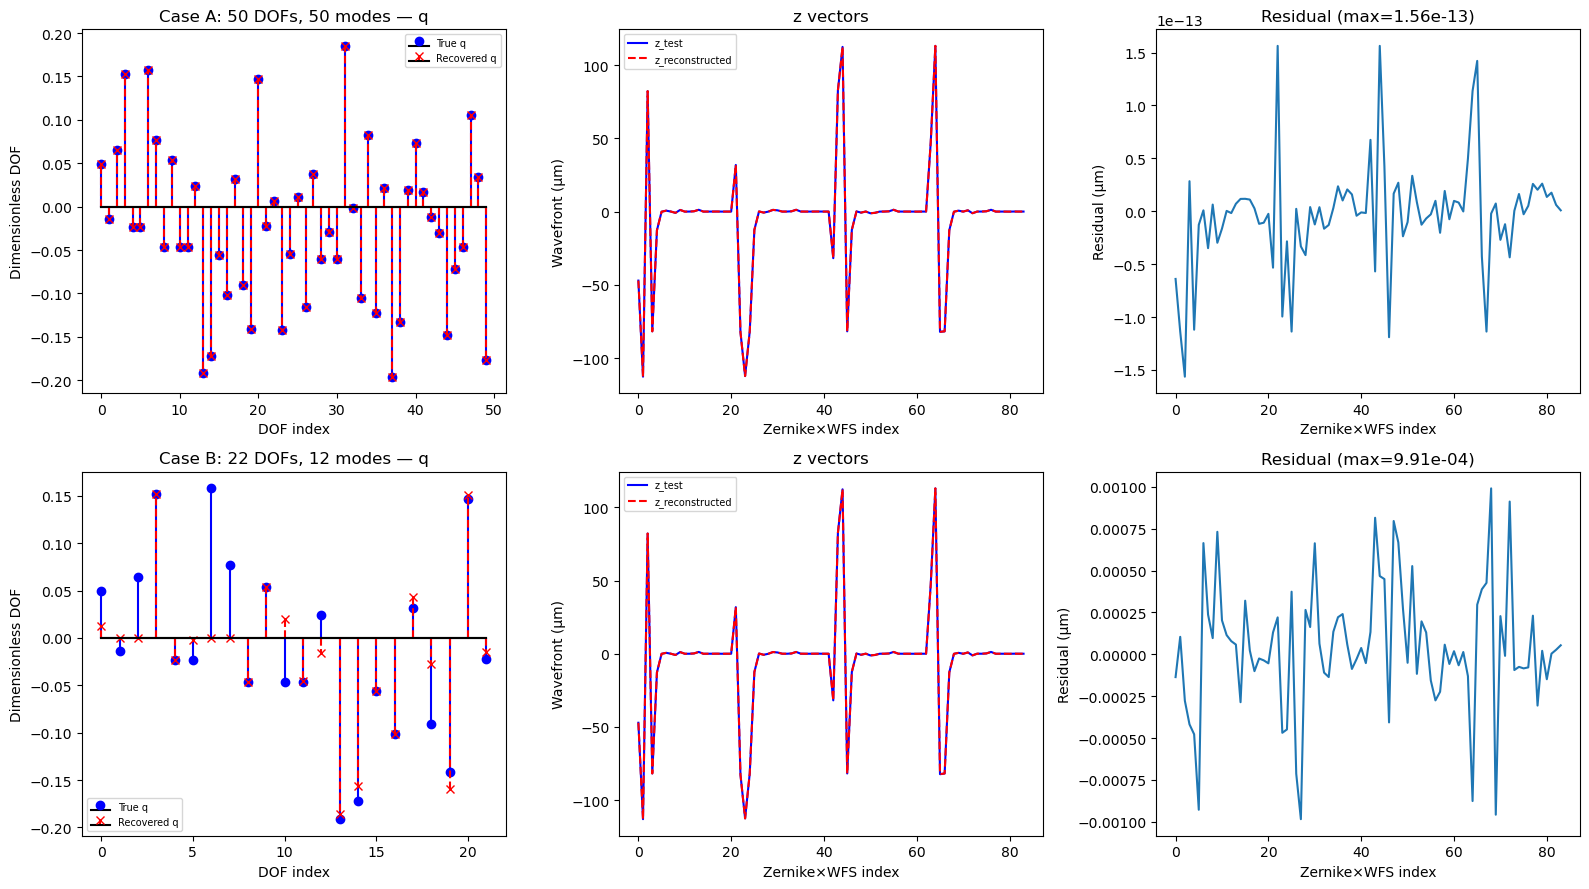

Case A (50 DOFs, 50 modes): DOF error = 2.45e-09,  z error = 1.41e-15
Case B (22 DOFs, 12 modes): DOF error = 4.85e-01,  z error = 1.06e-05

Case B has nonzero error because 10 of 22 v-modes are truncated.


In [27]:
pdf_section('5.2 Round-Trip Test')
def run_roundtrip_test(dof_set_name, n_modes_use, seed=42):
    """Run a round-trip test: generate z from known q, recover q, reconstruct z."""
    r = svd_results[dof_set_name]
    V = r['V']
    s = r['s']
    Atilde_sub = r['Atilde_sub']
    n_dof = len(r['dof_indices'])
    
    # Create a test Zernike vector from a known DOF perturbation
    np.random.seed(seed)
    q_true = np.random.randn(n_dof) * 0.1
    z_test = Atilde_sub @ q_true
    
    # Recover DOFs via truncated pseudoinverse
    q_recovered = dimensionless_dof_correction(z_test, r, n_modes_use=n_modes_use)
    
    # Reconstruct Zernike from recovered DOFs
    z_reconstructed = Atilde_sub @ q_recovered
    residual = z_test - z_reconstructed
    
    dof_err = np.linalg.norm(q_true - q_recovered) / np.linalg.norm(q_true)
    z_err = np.linalg.norm(residual) / np.linalg.norm(z_test)
    
    return q_true, q_recovered, z_test, z_reconstructed, residual, dof_err, z_err

# --- Case A: 50 DOFs, all 50 v-modes ---
q_true_A, q_rec_A, z_A, z_rec_A, res_A, dof_err_A, z_err_A = run_roundtrip_test('all_50', n_modes_use=50)

# --- Case B: 22 DOFs, 12 v-modes ---
q_true_B, q_rec_B, z_B, z_rec_B, res_B, dof_err_B, z_err_B = run_roundtrip_test('standard_22', n_modes_use=12)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Case A: top row
axes[0, 0].stem(q_true_A, linefmt='b-', markerfmt='bo', basefmt='k-', label='True q')
axes[0, 0].stem(q_rec_A, linefmt='r--', markerfmt='rx', basefmt='k-', label='Recovered q')
axes[0, 0].set_xlabel('DOF index')
axes[0, 0].set_ylabel('Dimensionless DOF')
axes[0, 0].set_title(f'Case A: 50 DOFs, 50 modes — q')
axes[0, 0].legend(fontsize=7)

axes[0, 1].plot(z_A, 'b-', label='z_test')
axes[0, 1].plot(z_rec_A, 'r--', label='z_reconstructed')
axes[0, 1].set_xlabel('Zernike×WFS index')
axes[0, 1].set_ylabel('Wavefront (µm)')
axes[0, 1].set_title('z vectors')
axes[0, 1].legend(fontsize=7)

axes[0, 2].plot(res_A)
axes[0, 2].set_xlabel('Zernike×WFS index')
axes[0, 2].set_ylabel('Residual (µm)')
axes[0, 2].set_title(f'Residual (max={np.max(np.abs(res_A)):.2e})')

# Case B: bottom row
axes[1, 0].stem(q_true_B, linefmt='b-', markerfmt='bo', basefmt='k-', label='True q')
axes[1, 0].stem(q_rec_B, linefmt='r--', markerfmt='rx', basefmt='k-', label='Recovered q')
axes[1, 0].set_xlabel('DOF index')
axes[1, 0].set_ylabel('Dimensionless DOF')
axes[1, 0].set_title(f'Case B: 22 DOFs, 12 modes — q')
axes[1, 0].legend(fontsize=7)

axes[1, 1].plot(z_B, 'b-', label='z_test')
axes[1, 1].plot(z_rec_B, 'r--', label='z_reconstructed')
axes[1, 1].set_xlabel('Zernike×WFS index')
axes[1, 1].set_ylabel('Wavefront (µm)')
axes[1, 1].set_title('z vectors')
axes[1, 1].legend(fontsize=7)

axes[1, 2].plot(res_B)
axes[1, 2].set_xlabel('Zernike×WFS index')
axes[1, 2].set_ylabel('Residual (µm)')
axes[1, 2].set_title(f'Residual (max={np.max(np.abs(res_B)):.2e})')

fig.tight_layout()
pdf_save(fig)
plt.show()

print(f'Case A (50 DOFs, 50 modes): DOF error = {dof_err_A:.2e},  z error = {z_err_A:.2e}')
print(f'Case B (22 DOFs, 12 modes): DOF error = {dof_err_B:.2e},  z error = {z_err_B:.2e}')
print(f'\nCase B has nonzero error because 10 of 22 v-modes are truncated.')

<a id='Noise Amplification' ></a>
## 6. Noise Amplification and Information Content

A mode with small σ_k amplifies measurement noise: the DOF correction scales as a_k / σ_k.
If measurement noise is σ_noise in each Zernike, the DOF noise in mode k scales as σ_noise / σ_k.

This section quantifies the noise amplification (1/σ_k), the effective condition number,
and the information content vs. truncation level.

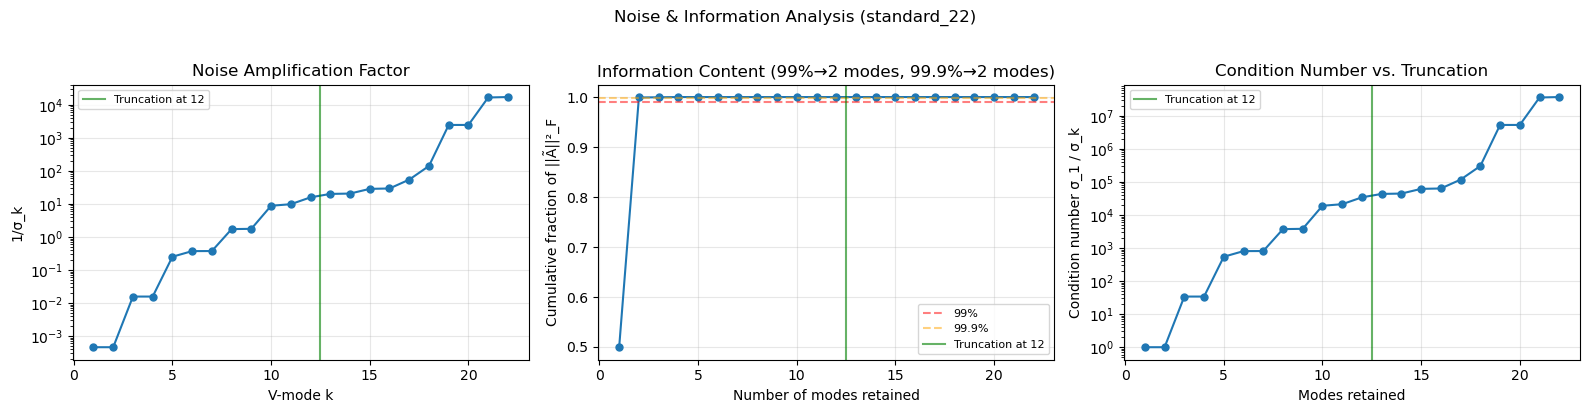

In [28]:
pdf_section('6. Noise Amplification and Information Content')
r = svd_results[default_dof_set]
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1/sigma_k: noise amplification factor (1-indexed)
axes[0].semilogy(np.arange(1, len(s) + 1), 1.0 / s, 'o-', markersize=5)
axes[0].axvline(n_trunc + 0.5, color='green', ls='-', alpha=0.6, label=f'Truncation at {n_trunc}')
axes[0].set_xlabel('V-mode k')
axes[0].set_ylabel('1/σ_k')
axes[0].set_title('Noise Amplification Factor')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Cumulative fraction of ||Ã||_F^2 captured (1-indexed)
s2_cumsum = np.cumsum(s**2)
s2_total = np.sum(s**2)
frac = s2_cumsum / s2_total
axes[1].plot(np.arange(1, len(s) + 1), frac, 'o-', markersize=5)
axes[1].axhline(0.99, color='red', ls='--', alpha=0.5, label='99%')
axes[1].axhline(0.999, color='orange', ls='--', alpha=0.5, label='99.9%')
axes[1].axvline(n_trunc + 0.5, color='green', ls='-', alpha=0.6, label=f'Truncation at {n_trunc}')
n99 = np.searchsorted(frac, 0.99) + 1
n999 = np.searchsorted(frac, 0.999) + 1
axes[1].set_xlabel('Number of modes retained')
axes[1].set_ylabel('Cumulative fraction of ||Ã||²_F')
axes[1].set_title(f'Information Content (99%→{n99} modes, 99.9%→{n999} modes)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Effective condition number vs. truncation level (1-indexed)
cond = [s[0] / s[k] for k in range(len(s))]
axes[2].semilogy(range(1, len(s) + 1), cond, 'o-', markersize=5)
axes[2].axvline(n_trunc + 0.5, color='green', ls='-', alpha=0.6, label=f'Truncation at {n_trunc}')
axes[2].set_xlabel('Modes retained')
axes[2].set_ylabel('Condition number σ_1 / σ_k')
axes[2].set_title('Condition Number vs. Truncation')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

fig.suptitle(f'Noise & Information Analysis ({default_dof_set})', fontsize=12, y=1.02)
fig.tight_layout()
pdf_save(fig)
plt.show()

### 6.1 Per-Zernike Measurement Noise from Atmospheric Turbulence

Load per-Zernike wavefront measurement noise from an atmospheric turbulence simulation (covM86.mat).
The covariance matrix gives the variance of each Zernike coefficient in nm², which we convert to µm.

In [ ]:
pdf_section('6.1 Per-Zernike Measurement Noise')
# Load per-Zernike measurement noise from covM86.mat
# covM is a 76x76 covariance matrix (4 WFS x 19 Zernikes, z4-z22), in nm^2
covm_data = scipy.io.loadmat('output/covM86.mat')
covM = covm_data['covM']
print(f'covM shape: {covM.shape}, units: nm^2')

# Extract per-Zernike sigma for the SVD's Zernike selection (zn_svd)
sigma_z_single = np.zeros(n_zk_svd)
for i, z in enumerate(zn_svd):
    if z <= 22:
        covm_idx = z - 4  # z4->0, z5->1, ..., z22->18
        sigma_z_single[i] = np.sqrt(covM[covm_idx, covm_idx]) / 1000.0  # nm -> um
    else:
        sigma_z_single[i] = 0.01  # default for z23+

print(f'\nPer-Zernike sigma (um) from atmospheric turbulence simulation:')
for i, z in enumerate(zn_svd):
    src = 'covM86' if z <= 22 else 'default'
    print(f'  z{z:2d}: sigma = {sigma_z_single[i]:.4f} um  ({src})')

# Replicate across WFS to get noise vector matching U dimensions
sigma_z_vec = np.tile(sigma_z_single, n_wfs)
print(f'\nFull noise vector shape: {sigma_z_vec.shape} ({n_wfs} WFS x {n_zk_svd} Zernikes)')

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.bar(range(n_zk_svd), sigma_z_single * 1000, color='steelblue')  # plot in nm
ax.set_xticks(range(n_zk_svd), [f'z{z}' for z in zn_svd], rotation=45, fontsize=8)
ax.set_ylabel('sigma_z (nm)')
ax.set_title('Per-Zernike Measurement Noise (from covM86 atmospheric simulation)')
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
pdf_save(fig)
plt.show()

In [ ]:
# DOF correction noise using per-Zernike measurement noise from covM86
# Cov(q) = V @ Σ⁻¹ @ Uᵀ @ diag(σ_z²) @ U @ Σ⁻¹ @ Vᵀ
# Uses U_wfs (WFS×Zernike space, not DZ coefficients)

r = svd_results[default_dof_set]
s = r['s']
V = r['V']
U_wfs = r['U_wfs']
n_dof_sub = len(r['dof_indices'])
labels_sub = r['labels']
n_sub = norm_vector[r['dof_indices']]

# Compute W = Σ⁻¹ @ U_wfsᵀ @ diag(σ_z), then Cov(q) = V @ W @ Wᵀ @ Vᵀ
Sigma_inv = np.diag(1.0 / s)
W = Sigma_inv @ U_wfs.T @ np.diag(sigma_z_vec)
Cov_q = V @ W @ W.T @ V.T
sigma_q = np.sqrt(np.diag(Cov_q))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(n_dof_sub), sigma_q, color='steelblue')
axes[0].set_xticks(range(n_dof_sub), labels_sub, rotation=90, fontsize=7)
axes[0].set_ylabel('σ(q_j) (dimensionless)')
axes[0].set_title('DOF Correction Noise (per-Zernike σ from covM86)')
axes[0].grid(alpha=0.3, axis='y')

# Physical DOF noise
sigma_phys = n_sub * sigma_q
axes[1].bar(range(n_dof_sub), sigma_phys, color='coral')
axes[1].set_xticks(range(n_dof_sub), labels_sub, rotation=90, fontsize=7)
axes[1].set_ylabel('σ(Δdof_j) (physical units)')
axes[1].set_title('Physical DOF Noise (per-Zernike σ from covM86)')
axes[1].grid(alpha=0.3, axis='y')

fig.tight_layout()
pdf_save(fig)
plt.show()

### 6.2 Effect of Truncation on Noise vs. Reconstruction Error

In [ ]:
pdf_section('6.2 Truncation vs. Noise Tradeoff')
r = svd_results[default_dof_set]
s = r['s']
U_wfs = r['U_wfs']
V = r['V']
n_modes_total = len(s)

# For each truncation level, compute:
# 1. Reconstruction error: ||Ã - Ã_trunc||_F / ||Ã||_F
# 2. Total DOF noise using per-Zernike sigma from covM86
recon_error = []
total_dof_noise = []

for n_keep in range(1, n_modes_total + 1):
    # Truncated reconstruction error
    residual_frac = np.sqrt(np.sum(s[n_keep:]**2)) / np.sqrt(np.sum(s**2))
    recon_error.append(residual_frac)
    
    # DOF noise from retained modes using per-Zernike noise (WFS space)
    Sigma_inv_trunc = np.diag(1.0 / s[:n_keep])
    W_trunc = Sigma_inv_trunc @ U_wfs[:, :n_keep].T @ np.diag(sigma_z_vec)
    Cov_q_trunc = V[:, :n_keep] @ W_trunc @ W_trunc.T @ V[:, :n_keep].T
    noise_var = np.trace(Cov_q_trunc)
    total_dof_noise.append(np.sqrt(noise_var))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.semilogy(range(1, n_modes_total + 1), recon_error, 'bo-', markersize=5, label='Reconstruction error')
ax2.semilogy(range(1, n_modes_total + 1), total_dof_noise, 'rs-', markersize=5, label='DOF noise')

ax1.set_xlabel('Modes retained')
ax1.set_ylabel('Fractional reconstruction error', color='blue')
ax2.set_ylabel('Total DOF noise (dimensionless)', color='red')
ax1.set_title(f'Truncation Tradeoff ({default_dof_set}, per-Zernike σ from covM86)')
ax1.grid(alpha=0.3)

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc='center right')

fig.tight_layout()
pdf_save(fig)
plt.show()

<a id='Control Gain' ></a>
## 7. Control Gain Analysis

The AOS control loop operates as a discrete-time feedback system:

1. **Measure:** Read out wavefront Zernike coefficients from the 4 corner WFS (84-element vector **z**)
2. **Project:** Compute v-mode amplitudes **a** = Uᵀ **z** — this decomposes the measured wavefront error into the independent correction modes
3. **Correct:** Compute the DOF correction **Δq** = −K_P × Σ⁻¹ **a** — the pseudoinverse (Σ⁻¹) converts wavefront amplitudes to dimensionless DOF motions, and K_P is the proportional gain that controls how aggressively we correct
4. **Apply:** Send physical corrections Δdof_j = n_j × Δq_j to the hexapod and mirror actuators. Due to the readout/computation pipeline, there is a multi-step delay before the correction takes effect.

**Why does σ_k matter for gain?**
The pseudoinverse divides each v-mode amplitude by its singular value σ_k. When the correction is applied, the optics respond with sensitivity σ_k. So the net effect of a full correction (K_P = 1) would be: the wavefront change equals σ_k × (a_k / σ_k) = a_k — a perfect one-step correction. The gain K_P < 1 intentionally reduces this to ensure stability in the presence of delay.

**Uniform gain K_P:**
The effective closed-loop gain for v-mode k is K_P (independent of σ_k for the uniform case). However, in practice the *sensitivity* to noise and model errors varies by mode — weak modes (small σ_k) amplify noise more because the pseudoinverse divides by a small number. The correction step for mode k is K_P × a_k / σ_k, so noise in a_k gets amplified by 1/σ_k before being multiplied by K_P.

**Per-mode gain scheduling:** Setting K_P(k) = gain_factor / σ_k gives each mode an effective correction fraction of gain_factor × a_k / σ_k × σ_k = gain_factor × a_k. But more importantly, it reduces the gain for noise-amplifying weak modes.

**Plots below:**
- **Left:** Effective gain K_P × σ_k per mode under uniform K_P — shows the spread across modes
- **Center:** The per-mode K_P(k) schedule — weaker modes get larger K_P to compensate
- **Right:** Convergence rate comparison: fraction of initial error remaining vs. image number

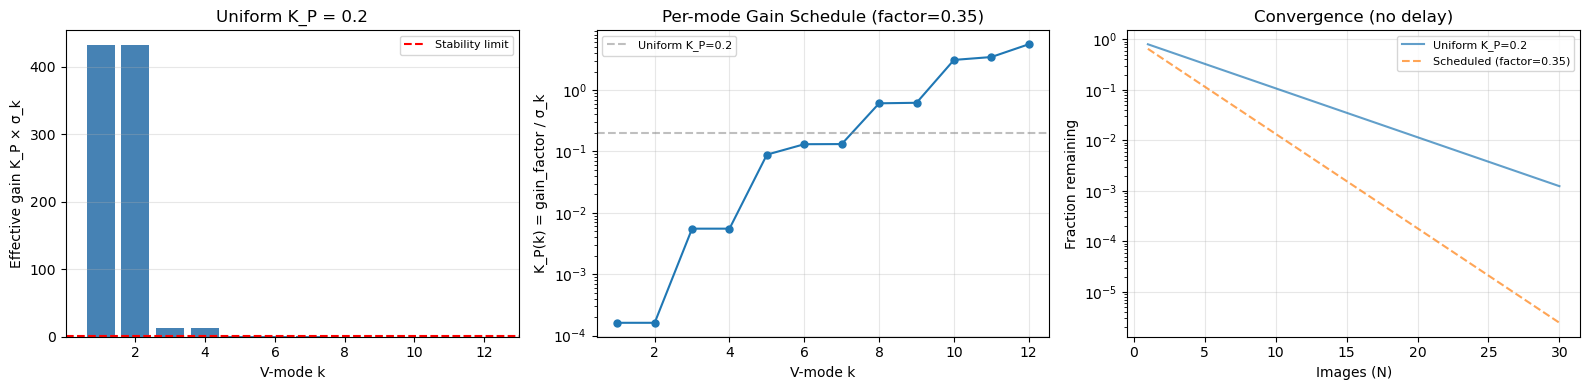

In [32]:
pdf_section('7. Control Gain Analysis')
r = svd_results[default_dof_set]
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]

# --- Uniform gain: all modes use the same K_P ---
# Effective gain per mode = K_P * sigma_k
# Large-sigma modes have high effective gain, small-sigma modes have low effective gain
K_P_uniform = 0.2
effective_gain_uniform = K_P_uniform * s[:n_trunc]

# --- Per-mode gain scheduling: K_P(k) = gain_factor / sigma_k ---
# This equalizes the effective gain to gain_factor for all modes
# Weak modes get a larger K_P to compensate for their small sigma_k
gain_factor = 0.35
K_P_per_mode = gain_factor / s[:n_trunc]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left: effective gain per mode under uniform K_P
axes[0].bar(np.arange(1, n_trunc + 1), effective_gain_uniform, color='steelblue')
axes[0].axhline(1.0, color='red', ls='--', label='Stability limit')
axes[0].set_xlabel('V-mode k')
axes[0].set_ylabel('Effective gain K_P × σ_k')
axes[0].set_title(f'Uniform K_P = {K_P_uniform}')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='y')

# Center: per-mode K_P values (log scale since they span a wide range)
axes[1].semilogy(np.arange(1, n_trunc + 1), K_P_per_mode, 'o-', markersize=5)
axes[1].axhline(K_P_uniform, color='gray', ls='--', alpha=0.5, label=f'Uniform K_P={K_P_uniform}')
axes[1].set_xlabel('V-mode k')
axes[1].set_ylabel('K_P(k) = gain_factor / σ_k')
axes[1].set_title(f'Per-mode Gain Schedule (factor={gain_factor})')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Right: convergence comparison — fraction of error remaining after N images
# With uniform K_P and no delay: a_k[n+1] = (1 - K_P) * a_k[n]
# With per-mode scheduling: a_k[n+1] = (1 - gain_factor) * a_k[n]
N = np.arange(1, 31)
pole_uniform = 1.0 - K_P_uniform
residual = pole_uniform**N
axes[2].plot(N, residual, '-', label=f'Uniform K_P={K_P_uniform}', alpha=0.7)

pole_sched = 1.0 - gain_factor
residual_sched = pole_sched**N
axes[2].plot(N, residual_sched, '--', label=f'Scheduled (factor={gain_factor})', alpha=0.7)

axes[2].set_xlabel('Images (N)')
axes[2].set_ylabel('Fraction remaining')
axes[2].set_title('Convergence (no delay)')
axes[2].set_yscale('log')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

fig.tight_layout()
pdf_save(fig)
plt.show()

### 7.1 Per-Mode Convergence with 2-Step Delay

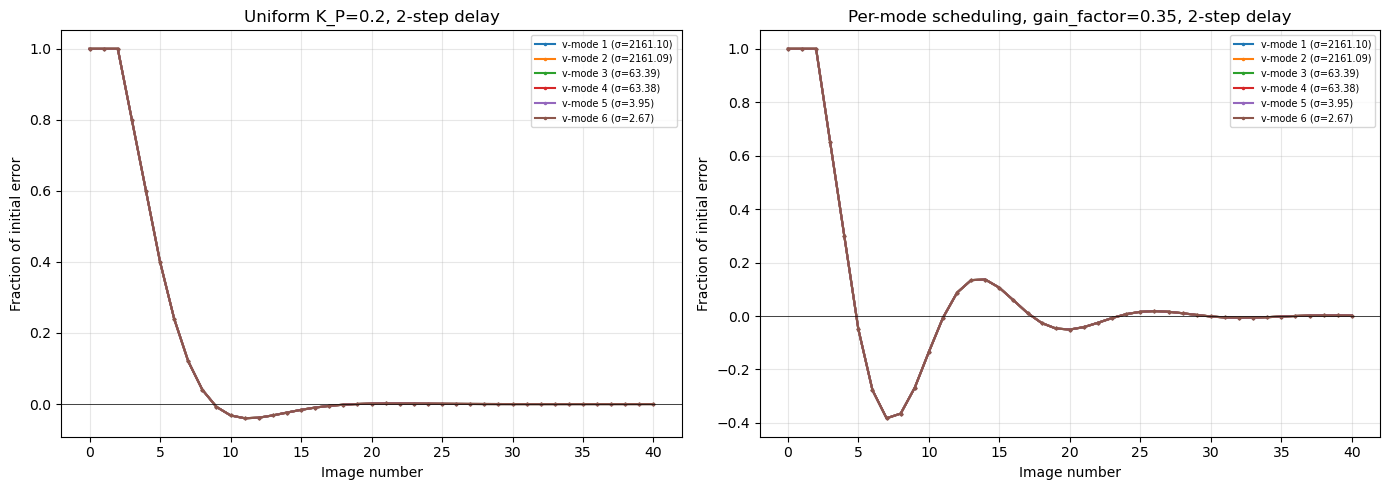

In [33]:
pdf_section('7.1 Per-Mode Convergence (2-Step Delay)')
# Simulate the discrete control loop with 2-step delay for each v-mode independently
# a_k[n+1] = a_k[n] - K_P * a_k[n - delay]

r = svd_results[default_dof_set]
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]
n_images = 40
delay = 2  # correction from image n applied before image n+3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uniform gain
K_P = 0.2
for k in range(min(6, n_trunc)):
    x = np.zeros(n_images + delay + 1)
    x[0] = 1.0
    for n in range(n_images):
        if n + 1 <= delay:
            x[n + 1] = x[n]
        else:
            x[n + 1] = x[n] - K_P * x[n - delay]
    axes[0].plot(range(n_images + 1), x[:n_images + 1], '.-', markersize=3,
                 label=f'v-mode {k+1} (σ={s[k]:.2f})')

axes[0].set_xlabel('Image number')
axes[0].set_ylabel('Fraction of initial error')
axes[0].set_title(f'Uniform K_P={K_P}, {delay}-step delay')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='k', lw=0.5)

# Per-mode gain scheduling: a_k[n+1] = a_k[n] - gain_factor * a_k[n-delay]
gain_factor = 0.35
for k in range(min(6, n_trunc)):
    x = np.zeros(n_images + delay + 1)
    x[0] = 1.0
    for n in range(n_images):
        if n + 1 <= delay:
            x[n + 1] = x[n]
        else:
            x[n + 1] = x[n] - gain_factor * x[n - delay]
    axes[1].plot(range(n_images + 1), x[:n_images + 1], '.-', markersize=3,
                 label=f'v-mode {k+1} (σ={s[k]:.2f})')

axes[1].set_xlabel('Image number')
axes[1].set_ylabel('Fraction of initial error')
axes[1].set_title(f'Per-mode scheduling, gain_factor={gain_factor}, {delay}-step delay')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='k', lw=0.5)

fig.tight_layout()
pdf_save(fig)
plt.show()

### 7.2 Per-Mode Convergence with 1-Step Delay

With a 1-step delay (correction from image n applied before image n+2), the system
converges faster than the 2-step case. This is the best-case scenario for the AOS loop.

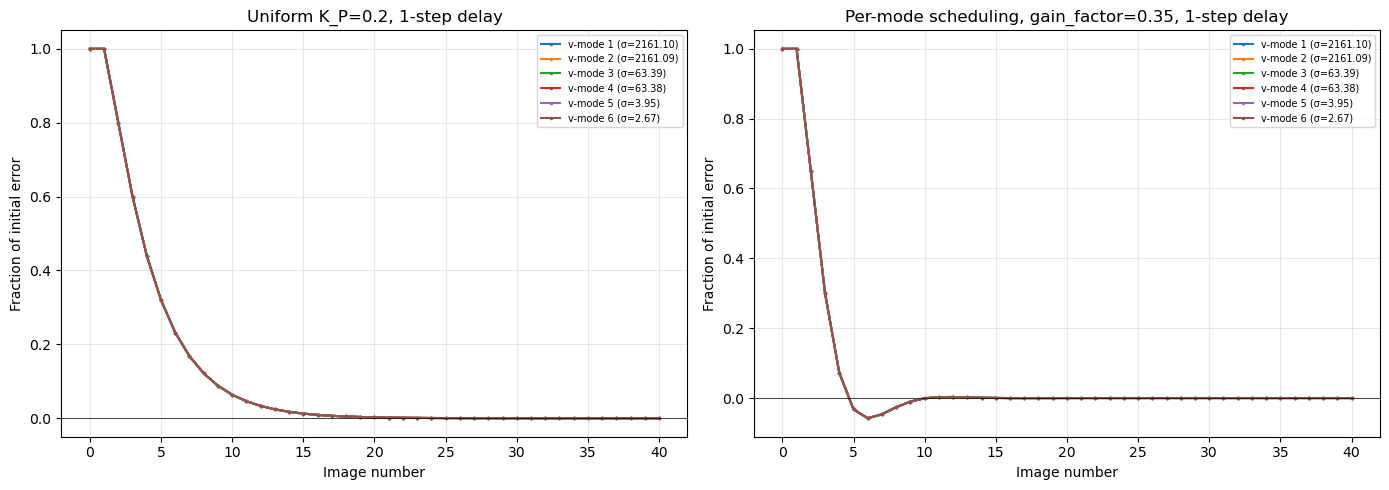

In [34]:
pdf_section('7.2 Per-Mode Convergence (1-Step Delay)')
# Simulate the discrete control loop with 1-step delay for each v-mode independently
# a_k[n+1] = a_k[n] - K_P * a_k[n - delay]

r = svd_results[default_dof_set]
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]
n_images = 40
delay = 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uniform gain
K_P = 0.2
for k in range(min(6, n_trunc)):
    x = np.zeros(n_images + delay + 1)
    x[0] = 1.0
    for n in range(n_images):
        if n + 1 <= delay:
            x[n + 1] = x[n]
        else:
            x[n + 1] = x[n] - K_P * x[n - delay]
    axes[0].plot(range(n_images + 1), x[:n_images + 1], '.-', markersize=3,
                 label=f'v-mode {k+1} (σ={s[k]:.2f})')

axes[0].set_xlabel('Image number')
axes[0].set_ylabel('Fraction of initial error')
axes[0].set_title(f'Uniform K_P={K_P}, {delay}-step delay')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='k', lw=0.5)

# Per-mode gain scheduling
gain_factor = 0.35
for k in range(min(6, n_trunc)):
    x = np.zeros(n_images + delay + 1)
    x[0] = 1.0
    for n in range(n_images):
        if n + 1 <= delay:
            x[n + 1] = x[n]
        else:
            x[n + 1] = x[n] - gain_factor * x[n - delay]
    axes[1].plot(range(n_images + 1), x[:n_images + 1], '.-', markersize=3,
                 label=f'v-mode {k+1} (σ={s[k]:.2f})')

axes[1].set_xlabel('Image number')
axes[1].set_ylabel('Fraction of initial error')
axes[1].set_title(f'Per-mode scheduling, gain_factor={gain_factor}, {delay}-step delay')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='k', lw=0.5)

fig.tight_layout()
pdf_save(fig)
plt.show()

### 7.3 Per-Mode Convergence with 3-Step Delay

With a 3-step delay (correction from image n not applied until image n+4), the system
converges more slowly and is more prone to oscillation. This represents a pessimistic
scenario for the AOS loop.

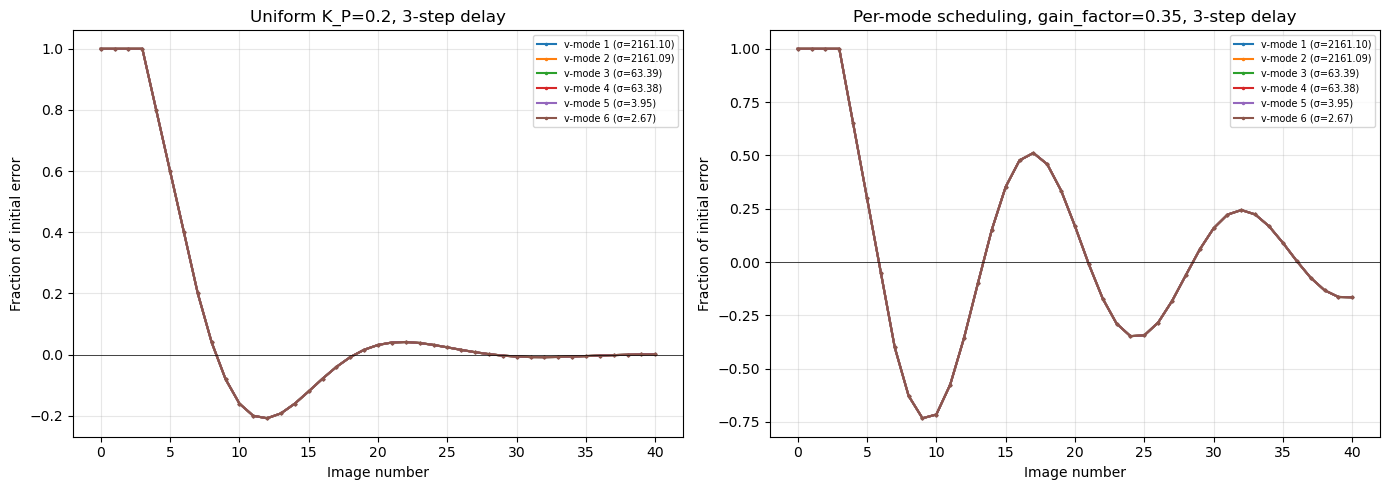

In [35]:
pdf_section('7.3 Per-Mode Convergence (3-Step Delay)')
# Simulate the discrete control loop with 3-step delay for each v-mode independently
# a_k[n+1] = a_k[n] - K_P * a_k[n - delay]

r = svd_results[default_dof_set]
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]
n_images = 40
delay = 3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uniform gain
K_P = 0.2
for k in range(min(6, n_trunc)):
    x = np.zeros(n_images + delay + 1)
    x[0] = 1.0
    for n in range(n_images):
        if n + 1 <= delay:
            x[n + 1] = x[n]
        else:
            x[n + 1] = x[n] - K_P * x[n - delay]
    axes[0].plot(range(n_images + 1), x[:n_images + 1], '.-', markersize=3,
                 label=f'v-mode {k+1} (σ={s[k]:.2f})')

axes[0].set_xlabel('Image number')
axes[0].set_ylabel('Fraction of initial error')
axes[0].set_title(f'Uniform K_P={K_P}, {delay}-step delay')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='k', lw=0.5)

# Per-mode gain scheduling
gain_factor = 0.35
for k in range(min(6, n_trunc)):
    x = np.zeros(n_images + delay + 1)
    x[0] = 1.0
    for n in range(n_images):
        if n + 1 <= delay:
            x[n + 1] = x[n]
        else:
            x[n + 1] = x[n] - gain_factor * x[n - delay]
    axes[1].plot(range(n_images + 1), x[:n_images + 1], '.-', markersize=3,
                 label=f'v-mode {k+1} (σ={s[k]:.2f})')

axes[1].set_xlabel('Image number')
axes[1].set_ylabel('Fraction of initial error')
axes[1].set_title(f'Per-mode scheduling, gain_factor={gain_factor}, {delay}-step delay')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='k', lw=0.5)

fig.tight_layout()
pdf_save(fig)
plt.show()

<a id='DOF Set Comparison' ></a>
## 8. Comparison Across DOF Sets

Compare SVD properties for different DOF subsets (10, 22, 30, 50 DOFs).

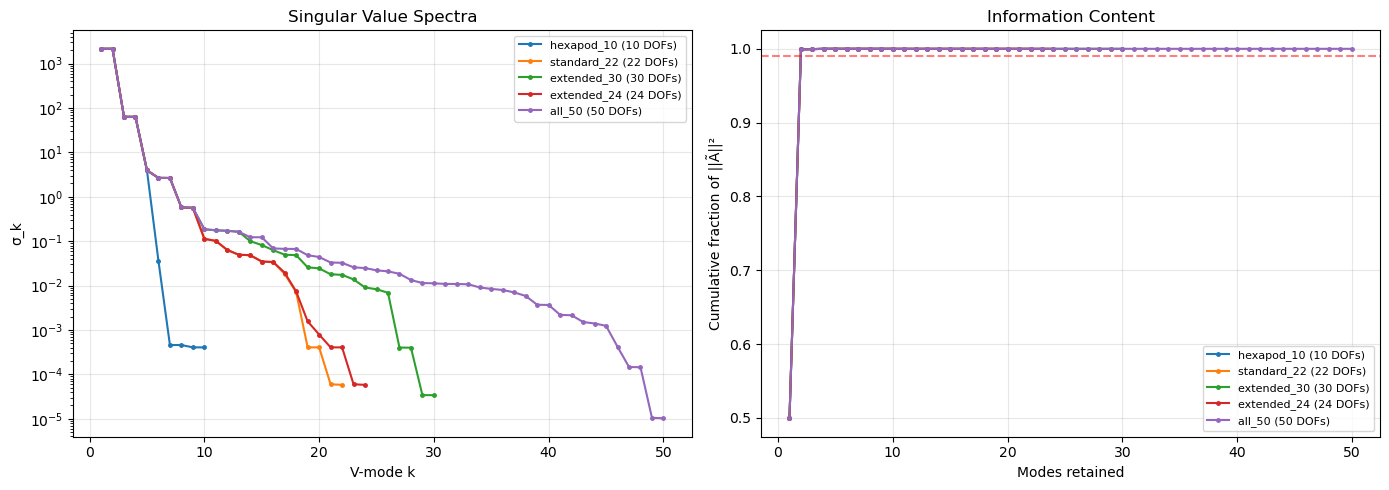

In [36]:
pdf_section('8. Comparison Across DOF Sets')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in svd_results.items():
    s = r['s']
    n = len(s)
    axes[0].semilogy(np.arange(1, n + 1), s, '.-', markersize=5, label=f'{name} ({n} DOFs)')
    
    s2_cumsum = np.cumsum(s**2)
    axes[1].plot(np.arange(1, n + 1), s2_cumsum / s2_cumsum[-1], '.-', markersize=5,
                 label=f'{name} ({n} DOFs)')

axes[0].set_xlabel('V-mode k')
axes[0].set_ylabel('σ_k')
axes[0].set_title('Singular Value Spectra')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].axhline(0.99, color='red', ls='--', alpha=0.5)
axes[1].set_xlabel('Modes retained')
axes[1].set_ylabel('Cumulative fraction of ||Ã||²')
axes[1].set_title('Information Content')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
pdf_save(fig)
plt.show()

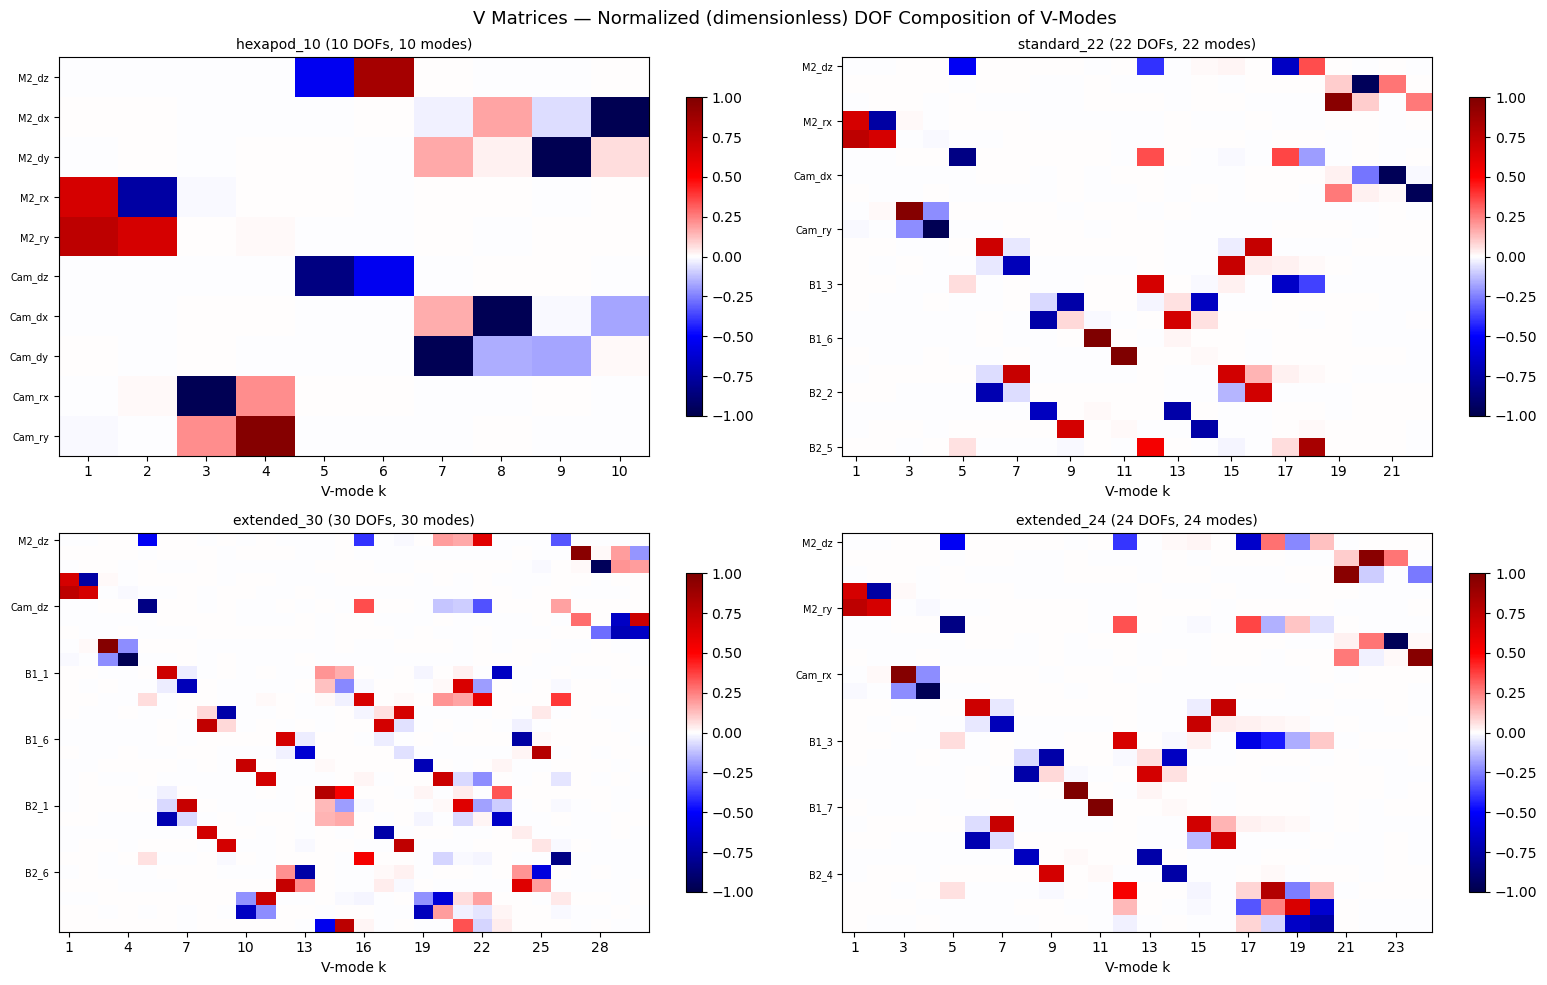

In [37]:
# V-matrix heatmaps for all DOF sets (1-indexed)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (name, r) in zip(axes.flat, svd_results.items()):
    V = r['V']
    labels_sub = r['labels']
    n_dof = len(labels_sub)
    n_modes = V.shape[1]
    im = ax.imshow(V, cmap='seismic', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(f'{name} ({n_dof} DOFs, {n_modes} modes)', fontsize=10)
    ax.set_xlabel('V-mode k')
    xt = np.arange(0, n_modes, max(1, n_modes // 10))
    ax.set_xticks(xt, [str(x + 1) for x in xt])
    yt = range(0, n_dof, max(1, n_dof // 6))
    ax.set_yticks(list(yt), [labels_sub[i] for i in yt], fontsize=7)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('V Matrices — Normalized (dimensionless) DOF Composition of V-Modes', fontsize=13)
fig.tight_layout()
pdf_save(fig)
plt.show()

<a id='DOF Set Comparisons' ></a>
## 9. DOF Set Comparisons

In [ ]:
pdf_tee_start()

pdf_section('9. DOF Set Comparisons')
print(f'{"DOF Set":>15s} {"n_DOF":>6s} {"n_trunc":>7s} {"σ_max":>10s} {"σ_min":>10s} '
      f'{"Cond #":>10s} {"99% modes":>10s} {"99.9% modes":>12s}')
print('-' * 90)

for name, r in svd_results.items():
    s = r['s']
    n_trunc = n_modes_truncated[name]
    frac = np.cumsum(s**2) / np.sum(s**2)
    n99 = np.searchsorted(frac, 0.99) + 1
    n999 = np.searchsorted(frac, 0.999) + 1
    print(f'{name:>15s} {len(r["dof_indices"]):>6d} {n_trunc:>7d} {s[0]:>10.3f} {s[-1]:>10.2e} '
          f'{s[0]/s[-1]:>10.1f} {n99:>10d} {n999:>12d}')

pdf_tee_stop()

<a id='Double-Zernike' ></a>
## 10. Double-Zernike V-Mode Decomposition

The double-Zernike basis describes wavefront patterns that are Zernike polynomial j over the pupil 
and Zernike polynomial k over the focal plane (Noll convention).

The focal plane positions are the 4 WFS corners. We use:
- **k_fp = 1** (constant over focal plane): field-averaged aberration
- **k_fp = 2** (x-tilt over focal plane): x-gradient of aberration
- **k_fp = 3** (y-tilt over focal plane): y-gradient of aberration

For each double-Zernike term (j, k_fp), we find:
1. Which v-modes are needed to produce this pattern
2. Whether the correction is "clean" (no crosstalk to other double-Zernike terms)

Analysis range: j = 4–11 for k_fp = 1; j = 4–8 for k_fp = 2, 3.

In [ ]:
pdf_tee_start()

pdf_section('10. Double-Zernike V-Mode Decomposition')
# --- Build the double-Zernike basis vectors ---
# Measurement vector layout matches StateEstimator's U:
#   index i = wfs_idx * n_zk_svd + zern_local_idx
# where zern_local_idx indexes into zn_svd array (0..n_zk_svd-1)

# Focal plane Zernike polynomials evaluated at 4 WFS positions
# WFS positions (field angles in degrees)
wfs_xy = np.array(field_angles)  # shape (4, 2)
print('WFS focal plane positions (deg):')
for i, (x, y) in enumerate(wfs_xy):
    print(f'  WFS{i}: ({x:.4f}, {y:.4f})')

# Normalize positions to unit circle radius = max distance from center
R_fp = np.max(np.sqrt(wfs_xy[:, 0]**2 + wfs_xy[:, 1]**2))
wfs_x_norm = wfs_xy[:, 0] / R_fp
wfs_y_norm = wfs_xy[:, 1] / R_fp
print(f'\nNormalization radius R_fp = {R_fp:.4f} deg')
print(f'Normalized WFS positions: x = {wfs_x_norm}, y = {wfs_y_norm}')

# Focal plane Zernike values (Noll convention):
# k_fp=1: Z_1 = 1 (piston/constant)
# k_fp=2: Z_2 = 2*x (tilt-x)
# k_fp=3: Z_3 = 2*y (tilt-y)
fp_zernike = {
    1: np.ones(n_wfs),                  # constant
    2: 2.0 * wfs_x_norm,               # x-tilt
    3: 2.0 * wfs_y_norm,               # y-tilt
}

fp_zernike_names = {1: 'const', 2: 'x-tilt', 3: 'y-tilt'}

print('\nFocal plane Zernike values at WFS positions:')
for kfp, vals in fp_zernike.items():
    print(f'  k_fp={kfp} ({fp_zernike_names[kfp]}): {vals}')

# Build double-Zernike basis vectors
# dz_vector(j, k_fp) has length n_wfs * n_zk_svd (matching U dimensions)
# Component at index (s * n_zk_svd + p) = delta(zn_svd[p], j) * Z_{k_fp}(wfs_s)
def make_dz_vector(j_noll, k_fp):
    """Create a double-Zernike basis vector for pupil Zernike j and focal plane Zernike k_fp."""
    vec = np.zeros(n_wfs * n_zk_svd)
    # Find the local index of j_noll in the SVD's Zernike array
    match = np.where(zn_svd == j_noll)[0]
    if len(match) == 0:
        return None  # j_noll not in Zernike selection
    p = match[0]  # local index
    fp_vals = fp_zernike[k_fp]
    for s in range(n_wfs):
        vec[s * n_zk_svd + p] = fp_vals[s]
    return vec

# Define the double-Zernike terms to analyze
dz_terms = []
# j = 4-15 for k_fp = 1
for j in range(4, 16):
    dz_terms.append((j, 1))
# j = 4-8 for k_fp = 2 and 3
for j in range(4, 9):
    dz_terms.append((j, 2))
for j in range(4, 9):
    dz_terms.append((j, 3))

print(f'\n{len(dz_terms)} double-Zernike terms to analyze:')
for j, kfp in dz_terms:
    print(f'  (j={j}, k_fp={kfp}) = z{j} x {fp_zernike_names[kfp]}')

# Build all DZ basis vectors
dz_vectors = {}
for j, kfp in dz_terms:
    vec = make_dz_vector(j, kfp)
    if vec is not None:
        dz_vectors[(j, kfp)] = vec
    else:
        print(f'  WARNING: z{j} not in Zernike selection, skipping (j={j}, k_fp={kfp})')

n_dz = len(dz_vectors)
print(f'\nBuilt {n_dz} double-Zernike basis vectors (length {n_wfs * n_zk_svd})')

pdf_tee_stop()

### 10.1 V-Mode Projections of Double-Zernike Terms

For each double-Zernike term (j, k_fp), project onto the U basis to find v-mode amplitudes:
**a_k = U^T_k @ dz_vector(j, k_fp)**

Then reconstruct and decompose back into double-Zernike components to check for crosstalk.

In [ ]:
pdf_tee_start()

pdf_section('10.1 V-Mode Projections of DZ Terms')
# --- Project each DZ term onto v-modes and check crosstalk ---
r = svd_results[default_dof_set]
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]

# Orthonormal U in WFS×Zernike space from SVD of Atilde_wfs
# (r['U_wfs'] is NOT orthonormal — it's Atilde_wfs @ V @ diag(1/s),
#  so projecting with it can give achievability > 1.0)
Atilde_wfs_dz = r['Atilde_wfs']
U_orth, _, _ = np.linalg.svd(Atilde_wfs_dz, full_matrices=False)

# Function to decompose a measurement vector into double-Zernike coefficients
def decompose_into_dz(z_vec, dz_vectors_dict):
    """Project z_vec onto each double-Zernike basis vector.
    
    Returns dict of (j, kfp) -> coefficient.
    Since DZ basis vectors are orthogonal for different (j, kfp) pairs
    (they have non-overlapping support), the projection is just the dot product
    divided by the norm squared.
    """
    coeffs = {}
    for (j, kfp), dz_vec in dz_vectors_dict.items():
        norm2 = np.dot(dz_vec, dz_vec)
        if norm2 > 0:
            coeffs[(j, kfp)] = np.dot(z_vec, dz_vec) / norm2
    return coeffs

# For each DZ term, compute:
# 1. v-mode amplitudes a_k
# 2. Fraction of DZ vector in the column space of Atilde (achievability)
# 3. Crosstalk: which other DZ terms are excited

dz_term_list = list(dz_vectors.keys())
n_dz = len(dz_term_list)

print(f'Double-Zernike V-Mode Analysis ({default_dof_set}, {n_trunc} retained modes)')
print('=' * 100)

# Store results for later plotting
dz_vmode_amps = {}   # (j, kfp) -> array of v-mode amplitudes
dz_achievable = {}   # (j, kfp) -> fraction achievable
dz_crosstalk = {}    # (j, kfp) -> dict of crosstalk coefficients

for j, kfp in dz_term_list:
    dz_vec = dz_vectors[(j, kfp)]
    
    # Project onto v-modes using orthonormal U (guarantees achievability <= 1)
    a = U_orth[:, :n_trunc].T @ dz_vec
    dz_vmode_amps[(j, kfp)] = a
    
    # Reconstruct from retained v-modes only
    z_reconstructed = U_orth[:, :n_trunc] @ a
    
    # Achievability: fraction of DZ vector captured
    frac_achieved = np.linalg.norm(z_reconstructed) / np.linalg.norm(dz_vec) if np.linalg.norm(dz_vec) > 0 else 0
    dz_achievable[(j, kfp)] = frac_achieved
    
    # Decompose the reconstructed vector into DZ components
    recon_dz_coeffs = decompose_into_dz(z_reconstructed, dz_vectors)
    dz_crosstalk[(j, kfp)] = recon_dz_coeffs
    
    # Print significant v-mode contributions (1-indexed)
    sig_modes = np.where(np.abs(a) > 0.01 * np.max(np.abs(a)))[0]
    mode_str = ', '.join([f'v{k+1}({a[k]:+.3f})' for k in sig_modes[:6]])
    
    # Check crosstalk
    self_coeff = recon_dz_coeffs.get((j, kfp), 0.0)
    xtalk_terms = [(jj, kk, c) for (jj, kk), c in recon_dz_coeffs.items() 
                   if (jj, kk) != (j, kfp) and abs(c) > 0.01 * abs(self_coeff) and abs(c) > 1e-6]
    
    xtalk_str = 'CLEAN' if len(xtalk_terms) == 0 else ', '.join(
        [f'z{jj}\u00d7{fp_zernike_names[kk]}({c:.3f})' for jj, kk, c in xtalk_terms[:4]])
    
    print(f'z{j}\u00d7{fp_zernike_names[kfp]:>7s}: achievable={frac_achieved:.4f}  '
          f'modes=[{mode_str}]  crosstalk: {xtalk_str}')

pdf_tee_stop()

### 10.2 V-Mode Amplitude Heatmap for Double-Zernike Terms

Each row is a double-Zernike term (j, k_fp), each column is a v-mode.
Color shows the amplitude a_k = U^T_k @ dz_vector(j, k_fp).

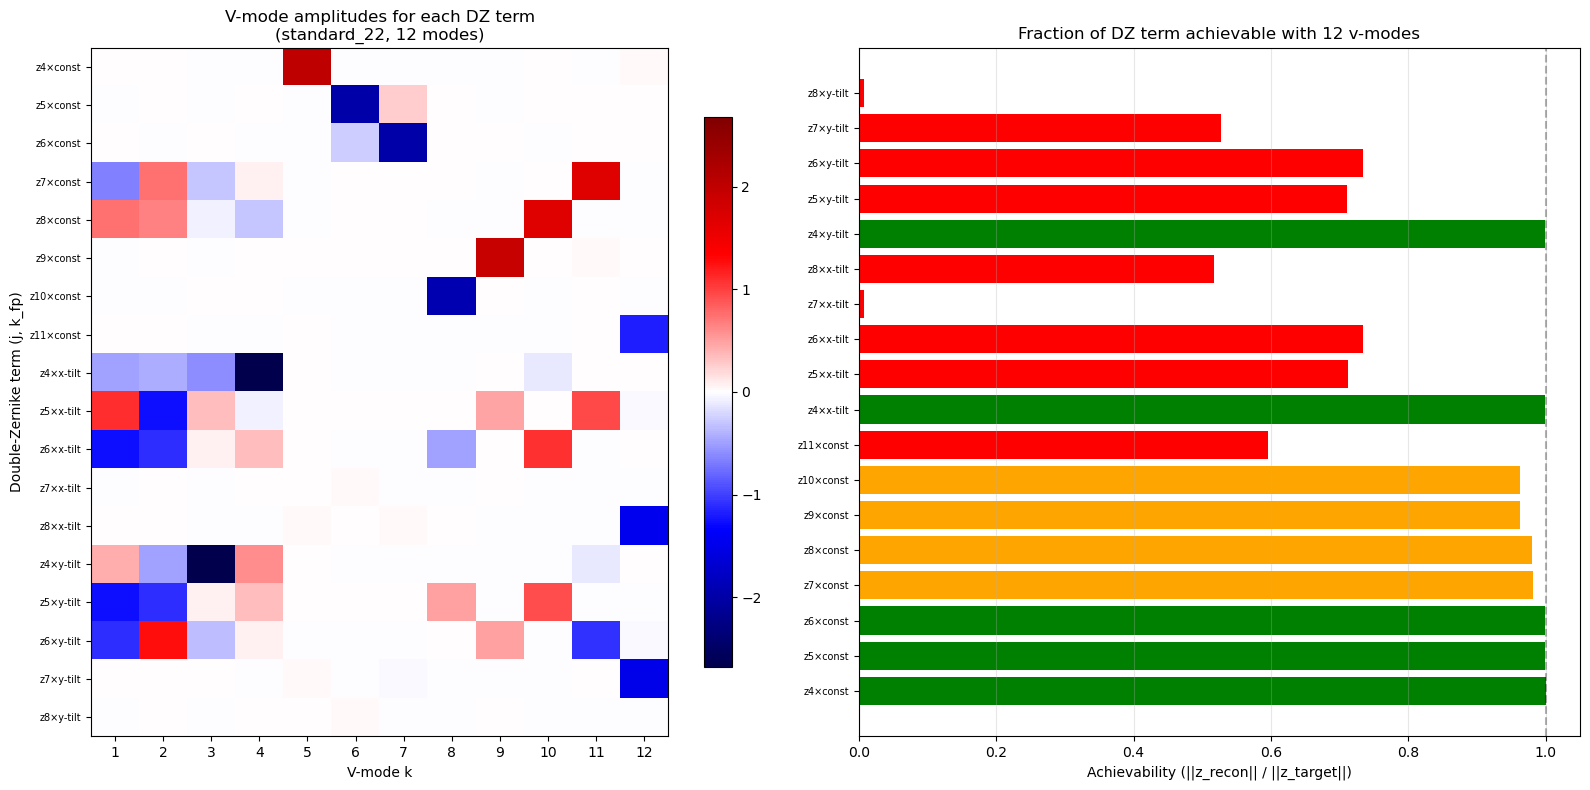

In [41]:
pdf_section('10.2 V-Mode Amplitude Heatmap for DZ Terms')
# Build the DZ → v-mode amplitude matrix
n_trunc = n_modes_truncated[default_dof_set]
amp_matrix = np.zeros((n_dz, n_trunc))
dz_labels = []
for i, (j, kfp) in enumerate(dz_term_list):
    amp_matrix[i, :] = dz_vmode_amps[(j, kfp)]
    dz_labels.append(f'z{j}×{fp_zernike_names[kfp]}')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap of v-mode amplitudes
vmax = np.max(np.abs(amp_matrix))
im = axes[0].imshow(amp_matrix, cmap='seismic', vmin=-vmax, vmax=vmax, aspect='auto')
axes[0].set_xlabel('V-mode k')
axes[0].set_xticks(range(n_trunc), [str(k+1) for k in range(n_trunc)])
axes[0].set_ylabel('Double-Zernike term (j, k_fp)')
axes[0].set_yticks(range(n_dz), dz_labels, fontsize=7)
axes[0].set_title(f'V-mode amplitudes for each DZ term\n({default_dof_set}, {n_trunc} modes)')
fig.colorbar(im, ax=axes[0], shrink=0.8)

# Achievability bar chart
achiev = [dz_achievable[(j, kfp)] for j, kfp in dz_term_list]
bar_colors = ['green' if a > 0.99 else 'orange' if a > 0.9 else 'red' for a in achiev]
axes[1].barh(range(n_dz), achiev, color=bar_colors)
axes[1].set_yticks(range(n_dz), dz_labels, fontsize=7)
axes[1].set_xlabel('Achievability (||z_recon|| / ||z_target||)')
axes[1].set_title(f'Fraction of DZ term achievable with {n_trunc} v-modes')
axes[1].axvline(1.0, color='k', ls='--', alpha=0.3)
axes[1].set_xlim(0, 1.05)
axes[1].grid(alpha=0.3, axis='x')

fig.tight_layout()
pdf_save(fig)
plt.show()

In [ ]:
# V-mode amplitude heatmaps for DZ terms across ALL DOF/truncation sets
# For each DOF set, recompute DZ projections using that set's orthonormal U

for dof_name in dof_sets.keys():
    r_i = svd_results[dof_name]
    n_trunc_i = n_modes_truncated[dof_name]
    Atilde_wfs_i = r_i['Atilde_wfs']
    U_orth_i, _, _ = np.linalg.svd(Atilde_wfs_i, full_matrices=False)

    # Project each DZ term onto this set's v-modes
    amp_matrix_i = np.zeros((n_dz, n_trunc_i))
    dz_labels_i = []
    for di, (j, kfp) in enumerate(dz_term_list):
        dz_vec = dz_vectors[(j, kfp)]
        a_i = U_orth_i[:, :n_trunc_i].T @ dz_vec
        amp_matrix_i[di, :] = a_i
        dz_labels_i.append(f'z{j}\u00d7{fp_zernike_names[kfp]}')

    # Achievability for this set
    achiev_i = []
    for j, kfp in dz_term_list:
        dz_vec = dz_vectors[(j, kfp)]
        a_i = U_orth_i[:, :n_trunc_i].T @ dz_vec
        z_recon = U_orth_i[:, :n_trunc_i] @ a_i
        frac = np.linalg.norm(z_recon) / np.linalg.norm(dz_vec) if np.linalg.norm(dz_vec) > 0 else 0
        achiev_i.append(frac)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    vmax = np.max(np.abs(amp_matrix_i))
    im = axes[0].imshow(amp_matrix_i, cmap='seismic', vmin=-vmax, vmax=vmax, aspect='auto')
    axes[0].set_xlabel('V-mode k')
    axes[0].set_xticks(range(n_trunc_i), [str(k+1) for k in range(n_trunc_i)])
    axes[0].set_ylabel('Double-Zernike term')
    axes[0].set_yticks(range(n_dz), dz_labels_i, fontsize=7)
    axes[0].set_title(f'V-mode amplitudes ({dof_name}, {n_trunc_i} modes)')
    fig.colorbar(im, ax=axes[0], shrink=0.8)

    bar_colors = ['green' if a > 0.99 else 'orange' if a > 0.9 else 'red' for a in achiev_i]
    axes[1].barh(range(n_dz), achiev_i, color=bar_colors)
    axes[1].set_yticks(range(n_dz), dz_labels_i, fontsize=7)
    axes[1].set_xlabel('Achievability')
    axes[1].set_title(f'Fraction achievable ({dof_name}, {n_trunc_i} modes)')
    axes[1].axvline(1.0, color='k', ls='--', alpha=0.3)
    axes[1].set_xlim(0, 1.05)
    axes[1].grid(alpha=0.3, axis='x')

    fig.tight_layout()
    pdf_save(fig)
    plt.show()

### 10.3 Crosstalk Matrix

The crosstalk matrix C(i, j) shows: when we try to correct DZ term i using the retained v-modes,
how much of DZ term j gets excited. Diagonal = self-correction (should be ~1 for achievable terms).
Off-diagonal = crosstalk (should be ~0 for clean corrections).

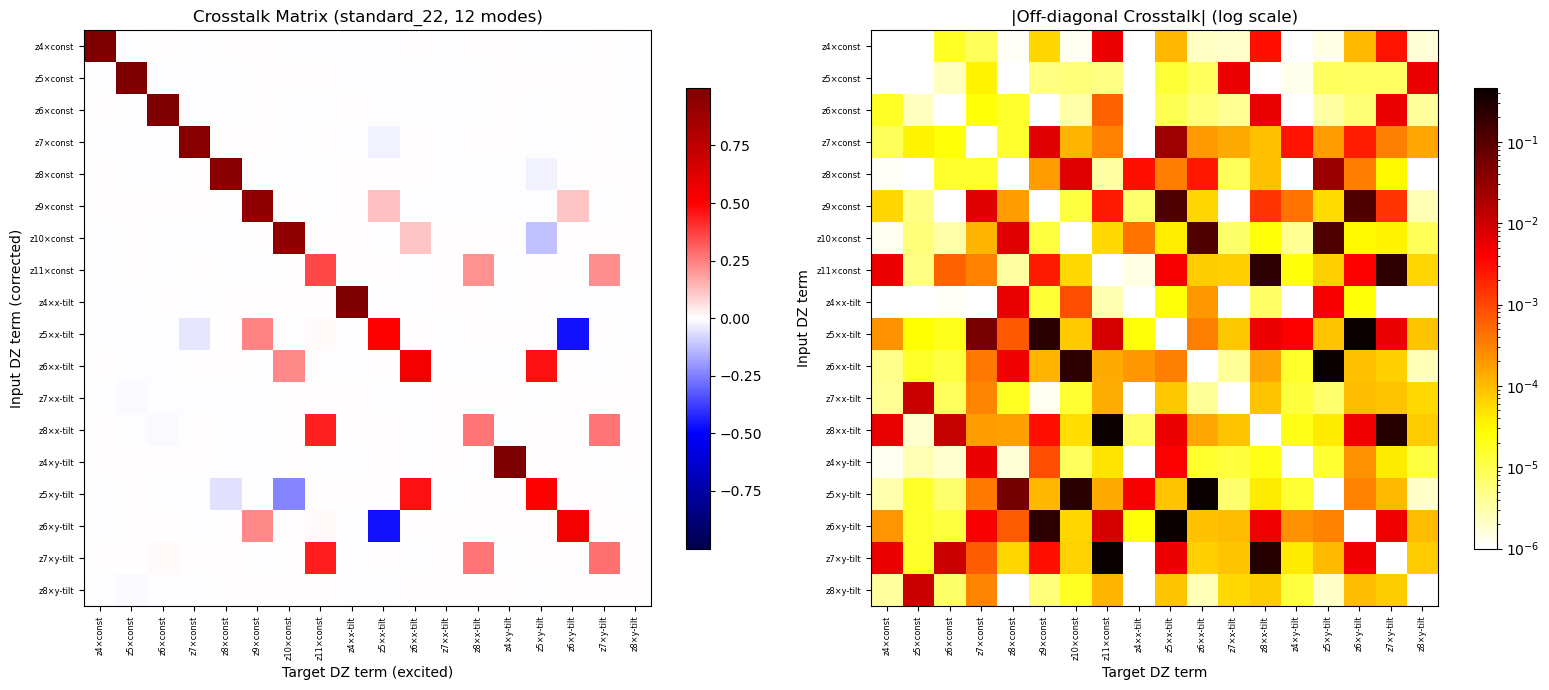


Max off-diagonal crosstalk per input DZ term:
  z4×  const: max |crosstalk| = 5.2842e-03  (worst: z11×const)
  z5×  const: max |crosstalk| = 5.3779e-03  (worst: z8×y-tilt)
  z6×  const: max |crosstalk| = 6.0748e-03  (worst: z8×x-tilt)
  z7×  const: max |crosstalk| = 2.6159e-02  (worst: z5×x-tilt)
  z8×  const: max |crosstalk| = 2.7732e-02  (worst: z5×y-tilt)
  z9×  const: max |crosstalk| = 1.1935e-01  (worst: z5×x-tilt)
  z10×  const: max |crosstalk| = 1.1965e-01  (worst: z5×y-tilt)
  z11×  const: max |crosstalk| = 2.2204e-01  (worst: z7×y-tilt)
  z4× x-tilt: max |crosstalk| = 5.8877e-03  (worst: z8×const)
  z5× x-tilt: max |crosstalk| = 4.6178e-01  (worst: z6×y-tilt)
  z6× x-tilt: max |crosstalk| = 4.6120e-01  (worst: z5×y-tilt)
  z7× x-tilt: max |crosstalk| = 1.0712e-02  (worst: z5×const)
  z8× x-tilt: max |crosstalk| = 4.3538e-01  (worst: z11×const)
  z4× y-tilt: max |crosstalk| = 5.6098e-03  (worst: z7×const)
  z5× y-tilt: max |crosstalk| = 4.6120e-01  (worst: z6×x-tilt)
  z6× y-t

In [42]:
pdf_section('10.3 Crosstalk Matrix')
# Build the crosstalk matrix
# C[i, j] = when correcting DZ term i, how much of DZ term j appears
n_trunc = n_modes_truncated[default_dof_set]
crosstalk_matrix = np.zeros((n_dz, n_dz))

for i, (j_i, kfp_i) in enumerate(dz_term_list):
    xtalk = dz_crosstalk[(j_i, kfp_i)]
    for ii, (j_ii, kfp_ii) in enumerate(dz_term_list):
        crosstalk_matrix[i, ii] = xtalk.get((j_ii, kfp_ii), 0.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full crosstalk matrix
vmax = np.max(np.abs(crosstalk_matrix))
im = axes[0].imshow(crosstalk_matrix, cmap='seismic', vmin=-vmax, vmax=vmax, aspect='auto')
axes[0].set_xlabel('Target DZ term (excited)')
axes[0].set_ylabel('Input DZ term (corrected)')
axes[0].set_xticks(range(n_dz), dz_labels, rotation=90, fontsize=6)
axes[0].set_yticks(range(n_dz), dz_labels, fontsize=6)
axes[0].set_title(f'Crosstalk Matrix ({default_dof_set}, {n_trunc} modes)')
fig.colorbar(im, ax=axes[0], shrink=0.8)

# Off-diagonal crosstalk magnitude (log scale)
offdiag = crosstalk_matrix.copy()
np.fill_diagonal(offdiag, 0)
vmax_off = np.max(np.abs(offdiag))
if vmax_off > 0:
    im2 = axes[1].imshow(np.abs(offdiag), norm=colors.LogNorm(vmin=1e-6, vmax=max(vmax_off, 1e-5)),
                          aspect='auto', cmap='hot_r')
else:
    im2 = axes[1].imshow(np.abs(offdiag), aspect='auto', cmap='hot_r')
axes[1].set_xlabel('Target DZ term')
axes[1].set_ylabel('Input DZ term')
axes[1].set_xticks(range(n_dz), dz_labels, rotation=90, fontsize=6)
axes[1].set_yticks(range(n_dz), dz_labels, fontsize=6)
axes[1].set_title(f'|Off-diagonal Crosstalk| (log scale)')
fig.colorbar(im2, ax=axes[1], shrink=0.8)

fig.tight_layout()
pdf_save(fig)
plt.show()

# Print max off-diagonal crosstalk per DZ term
print(f'\nMax off-diagonal crosstalk per input DZ term:')
for i, (j, kfp) in enumerate(dz_term_list):
    row = offdiag[i, :]
    max_xt = np.max(np.abs(row))
    if max_xt > 1e-6:
        worst_idx = np.argmax(np.abs(row))
        j_w, kfp_w = dz_term_list[worst_idx]
        print(f'  z{j}×{fp_zernike_names[kfp]:>7s}: max |crosstalk| = {max_xt:.4e}  '
              f'(worst: z{j_w}×{fp_zernike_names[kfp_w]})')
    else:
        print(f'  z{j}×{fp_zernike_names[kfp]:>7s}: CLEAN (max |crosstalk| < 1e-6)')

### 10.4 V-Mode Recipes for Individual Double-Zernike Terms

For selected double-Zernike terms, show the v-mode amplitude bar charts and verify
that the reconstruction matches only the target term.

In [ ]:
pdf_section('10.4 V-Mode Recipes for DZ Terms')
# Detailed plots for k_fp=1 (constant) DZ terms: z4-z11
r = svd_results[default_dof_set]
U = U_orth  # orthonormal U in WFS×Zernike space
n_trunc = n_modes_truncated[default_dof_set]

dz_kfp1 = [(j, 1) for j in range(4, 16) if (j, 1) in dz_vmode_amps]
n_plots = len(dz_kfp1)

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for idx, (ax, (j, kfp)) in enumerate(zip(axes.flat, dz_kfp1)):
    a = dz_vmode_amps[(j, kfp)]
    bar_colors = ['steelblue' if abs(v) > 0.01 * np.max(np.abs(a)) else 'lightgray' for v in a]
    ax.bar(np.arange(1, n_trunc + 1), a, color=bar_colors)
    ax.set_xlabel('V-mode k', fontsize=8)
    ax.set_ylabel('Amplitude a_k', fontsize=8)
    achiev = dz_achievable[(j, kfp)]
    ax.set_title(f'z{j}×const  (achiev={achiev:.3f})', fontsize=9)
    ax.grid(alpha=0.2, axis='y')
    ax.axhline(0, color='k', lw=0.5)

fig.suptitle(f'V-mode amplitudes for k_fp=1 (constant) DZ terms ({default_dof_set})', fontsize=12)
fig.tight_layout()
pdf_save(fig)
plt.show()

# Detailed plots for k_fp=2 and k_fp=3 (x-tilt and y-tilt): z4-z8
dz_kfp23 = [(j, 2) for j in range(4, 9)] + [(j, 3) for j in range(4, 9)]
n_plots = len(dz_kfp23)

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for idx, (ax, (j, kfp)) in enumerate(zip(axes.flat, dz_kfp23)):
    a = dz_vmode_amps[(j, kfp)]
    bar_colors = ['coral' if abs(v) > 0.01 * np.max(np.abs(a)) else 'lightgray' for v in a]
    ax.bar(np.arange(1, n_trunc + 1), a, color=bar_colors)
    ax.set_xlabel('V-mode k', fontsize=8)
    ax.set_ylabel('Amplitude a_k', fontsize=8)
    achiev = dz_achievable[(j, kfp)]
    ax.set_title(f'z{j}×{fp_zernike_names[kfp]}  (achiev={achiev:.3f})', fontsize=9)
    ax.grid(alpha=0.2, axis='y')
    ax.axhline(0, color='k', lw=0.5)

fig.suptitle(f'V-mode amplitudes for k_fp=2,3 (tilt) DZ terms ({default_dof_set})', fontsize=12)
fig.tight_layout()
pdf_save(fig)
plt.show()

### 10.5 Verification: Reconstruct Each DZ Term and Check Purity

For each double-Zernike term, reconstruct the wavefront from the v-mode recipe and decompose 
it back into all double-Zernike coefficients. Verify that only the intended term is non-zero.

In [ ]:
pdf_tee_start()

pdf_section('10.5 DZ Term Purity Verification')
# Detailed verification for each DZ term
r = svd_results[default_dof_set]
U = U_orth  # orthonormal U in WFS×Zernike space
n_trunc = n_modes_truncated[default_dof_set]

print(f'DZ Term Purity Check ({default_dof_set}, {n_trunc} retained modes)')
print(f'{"DZ term":>16s} {"self coeff":>11s} {"achievable":>11s} {"max xtalk":>11s} {"xtalk term":>16s} {"pure?":>6s}')
print('-' * 80)

n_clean = 0
n_total = 0
for j, kfp in dz_term_list:
    dz_vec = dz_vectors[(j, kfp)]
    
    # Project onto retained v-modes and reconstruct
    a = U[:, :n_trunc].T @ dz_vec
    z_recon = U[:, :n_trunc] @ a
    
    # Decompose reconstruction into all DZ terms
    recon_coeffs = decompose_into_dz(z_recon, dz_vectors)
    
    self_coeff = recon_coeffs.get((j, kfp), 0.0)
    achiev = dz_achievable[(j, kfp)]
    
    # Find worst crosstalk
    max_xtalk = 0.0
    worst_term = None
    for (jj, kkfp), c in recon_coeffs.items():
        if (jj, kkfp) != (j, kfp) and abs(c) > max_xtalk:
            max_xtalk = abs(c)
            worst_term = (jj, kkfp)
    
    is_pure = max_xtalk < 1e-4 * abs(self_coeff) if abs(self_coeff) > 0 else max_xtalk < 1e-10
    n_total += 1
    if is_pure:
        n_clean += 1
    
    worst_str = f'z{worst_term[0]}×{fp_zernike_names[worst_term[1]]}' if worst_term else 'n/a'
    pure_str = 'YES' if is_pure else 'NO'
    
    print(f'z{j}×{fp_zernike_names[kfp]:>7s}  {self_coeff:>11.6f}  {achiev:>11.4f}  '
          f'{max_xtalk:>11.2e}  {worst_str:>16s}  {pure_str:>6s}')

print(f'\nSummary: {n_clean}/{n_total} DZ terms have pure (no crosstalk) v-mode recipes')
print(f'Note: "pure" means max |crosstalk| < 1e-4 × |self coefficient|')

pdf_tee_stop()

In [ ]:
# Close the PDF file
pdf.close()
print(f'PDF saved: {pdf_filename}')